# Models evaluation - Test 3 (Synthetic Copy)

Hello! This notebook documents the code that was written to evalutate the models on different capabilities. We also include results of the evaluations. 

Here we will be testing the models on the synthetic copy test - the models are tasked with processing a text composed of N true and M noise tokens (the noise tokens are uniform), and then with outputting the N true tokens.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from tqdm.notebook import trange, tqdm
import matplotlib.pyplot as plt
import random

# Build vocab for all models & tests. 
# We employ the same vocab size to be fair 

vocab = dict()

characters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ{.}()[]|"

for i in range(10):
    vocab[str(i)] = i

for char in characters:
    vocab[char] = len(vocab)

for i in range(100):
    vocab[f"NOISE_{i}"] = len(vocab)

vocab["<ENDSEQ>"] = len(vocab)
vocab["<STABLENOISE>"] = len(vocab)
vocab["<STARTTASK>"] = len(vocab)
vocab["<EOS>"] = len(vocab)

In [3]:
def get_batch_ex3(batch_size, vocab, copy_size=5, buffer_size=50, device="cuda"):

    first_noise_ix = vocab["NOISE_0"]
    last_noise_ix = vocab["NOISE_99"]

    # Random noise
    noise_tensor = torch.randint(first_noise_ix, last_noise_ix + 1, (batch_size, buffer_size), device=device )

    # Random digits
    copy_tensor = torch.randint(0, 10, (batch_size, copy_size), device=device)

    # Choose positions for the digits.
    # Each row gets its own random positions.
    positions = (torch.rand(batch_size, buffer_size, device=device).argsort(dim=-1)[..., :copy_size].sort(dim=-1).values)

    # Put the digits into the noise
    ready_tensor = noise_tensor.clone()

    ready_tensor.scatter_(dim=-1, index=positions, src=copy_tensor)

    marker_tensor = torch.full(
        (batch_size, 1),
        vocab["<STARTTASK>"],
        device=device,
    )

    ready_tensor = torch.cat([ready_tensor, marker_tensor], dim=-1)

    return F.one_hot(ready_tensor, num_classes=len(vocab)).float(), copy_tensor.sort(dim=-1).values

def evaluate_ex3(model, copy_size, buffer_size, total_batches, batch_size, vocab, teacher_forcing=True, diagnostic=False):

    print("Testing model at ", buffer_size, " buffer_size.")

    avg_difference_sum = 0
    with torch.no_grad():
        model.eval()
        for batch_num in trange(total_batches + 1): #We want to get to the end of the user-specified range.

            batch, targets = get_batch_ex3(batch_size, vocab, copy_size, buffer_size) #targets = (batch, seq)
            model_targets = F.one_hot(targets, num_classes=len(vocab)).float()

            if teacher_forcing==False:
                logits = model.predict_inference(
                    x=batch,
                    vocab=vocab,
                    max_len=copy_size-1
                )
            else:
                logits = model.forward(batch, model_targets) # (batch, seq, emb)
            tokens = torch.argmax(logits, dim=2) # (batch, seq)

            difference = targets - tokens #we'll get some number where the numbers are not the same

            difference = (difference !=0).float()

            num_elements = copy_size * batch_size

            num_different = torch.sum(difference)

            avg_difference = num_different / num_elements

            avg_difference_sum = avg_difference_sum + avg_difference.item()

            if diagnostic==True and batch_num == total_batches:
                print("True targets: ", targets)
                print("Predictions: ", tokens)

        model.train()

    return avg_difference_sum / (total_batches+1)



In [4]:

def plot_loss_curves(steps, train_history, test_history, model_name="Model"):
    plt.figure(figsize=(8, 5))
    plt.plot(steps, train_history, label='Train Loss', color='teal', linewidth=2)
    plt.plot(steps, test_history, label='Test Loss', color='orange', linestyle='--', linewidth=2)
    plt.xlabel('Training Steps')
    plt.ylabel('Cross-Entropy Loss')
    plt.title(f'{model_name} Sequential sorting noise filtering task')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def save_model(model, optimizer, epoch_saved, model_name, note):
    checkpoint = {
        "epoch_saved": epoch_saved,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict()
    }
    name = '_'.join(model_name.split()) + "_" + '_'.join(note.split()) + "_epoch_" + str(epoch_saved) + ".pt"
    torch.save(checkpoint, name)

def run_training_ex3(model, batch_size, total_batches, test_batches, copy_size, buffer_size, opt, test_break, model_name,
                     steps_history, train_history, test_history, vocab):
    training_loss = 0

    for batch_num in trange(total_batches + 1):

        act_buffer_size = random.randint(100, buffer_size)

        batch, targets = get_batch_ex3(batch_size, vocab, copy_size, act_buffer_size)

        model_targets = F.one_hot(targets, num_classes=len(vocab)).float()

        #print(model_targets.shape)

        opt.zero_grad()

        logits = model.forward(batch, model_targets)
        loss_t = F.cross_entropy(logits.transpose(1, 2), targets)

        loss_t.backward()

        opt.step()

        training_loss = training_loss + loss_t.item()

        if batch_num % 1000 == 0 and batch_num != 0:
            save_model(model, opt, epoch_saved=batch_num, model_name=model_name, note="ex3")

        if batch_num % test_break == 0:

            with torch.no_grad():
                total_loss = 0
                avg_training_loss = training_loss / test_break
                training_loss = 0

                model.eval()

                for test_batch_num in trange(test_batches):
                    batch, targets = get_batch_ex3(batch_size, vocab, copy_size, buffer_size)
                    model_targets = F.one_hot(targets, num_classes=len(vocab)).float()
                    logits = model.forward(batch, model_targets)
                    loss_t = F.cross_entropy(logits.transpose(1,2), targets)
                    total_loss = total_loss + loss_t.item()

                model.train()

                avg_testing_loss = total_loss / test_batches

                steps_history.append(batch_num)
                train_history.append(avg_training_loss)
                test_history.append(avg_testing_loss)

                plot_loss_curves(steps_history, train_history, test_history, model_name=model_name)

                print(f"STEP: {batch_num} | TRAIN LOSS: {avg_training_loss:.4f} | TEST LOSS: {avg_testing_loss:.4f}")


## Training

After code definition, we train the models.

In [5]:
import custom_models

hid=256
m_hid=16
emb=len(vocab)
lr=1e-3
batch_size=32
total_batches=7000
test_batches=10
copy_size=10
buffer_size=100

steps_history = []
train_history = []
test_history = []

device="cuda"



sLSTM_model = custom_models.sLSTM(hid, emb, device="cuda")
opt_sLSTM = torch.optim.Adam(sLSTM_model.parameters(), lr=lr)

MGU_model = custom_models.MRRN(hid, emb, device="cuda")
opt_MGU = torch.optim.Adam(MGU_model.parameters(), lr=lr)

GRU_model = custom_models.CopyGRU(hid, emb, device="cuda")
opt_GRU = torch.optim.Adam(GRU_model.parameters(), lr=lr)

maGRU_model = custom_models.maGRU(hid, emb, device="cuda")
opt_maGRU = torch.optim.Adam(maGRU_model.parameters(), lr=lr)

eGRU_model = custom_models.eGRU(hid, emb, device="cuda")
opt_eGRU = torch.optim.Adam(eGRU_model.parameters(), lr=lr)

mLSTM_model = custom_models.mLSTM(m_hid, emb, device=device)
opt_mLSTM = torch.optim.Adam(mLSTM_model.parameters(), lr=lr)

mLSTMLite_model = custom_models.mLSTMLite(m_hid, emb, device=device)
opt_mLSTMLite = torch.optim.Adam(mLSTMLite_model.parameters(), lr=lr)

LSTM_model = custom_models.CopyLSTM(hid, emb, device="cuda")
opt_LSTM = torch.optim.Adam(LSTM_model.parameters(), lr=lr)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

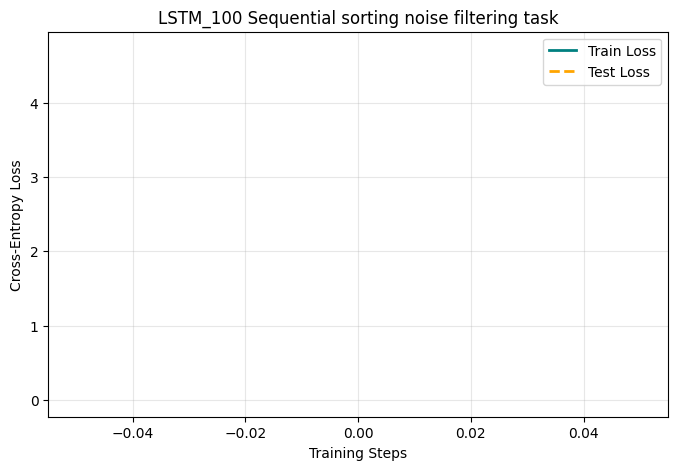

STEP: 0 | TRAIN LOSS: 0.0098 | TEST LOSS: 4.7216


  0%|          | 0/10 [00:00<?, ?it/s]

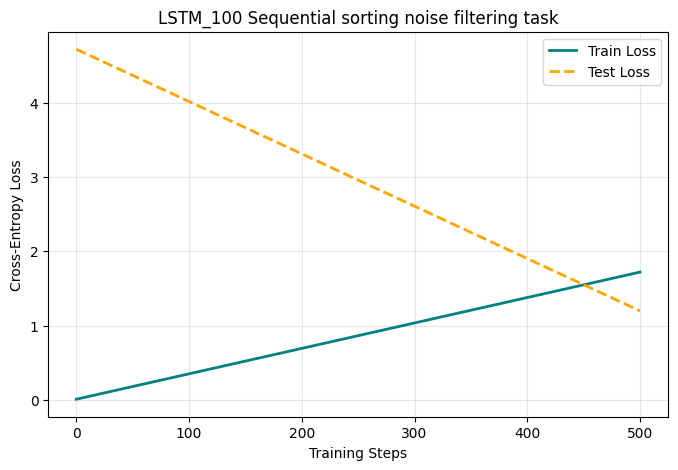

STEP: 500 | TRAIN LOSS: 1.7209 | TEST LOSS: 1.1994


  0%|          | 0/10 [00:00<?, ?it/s]

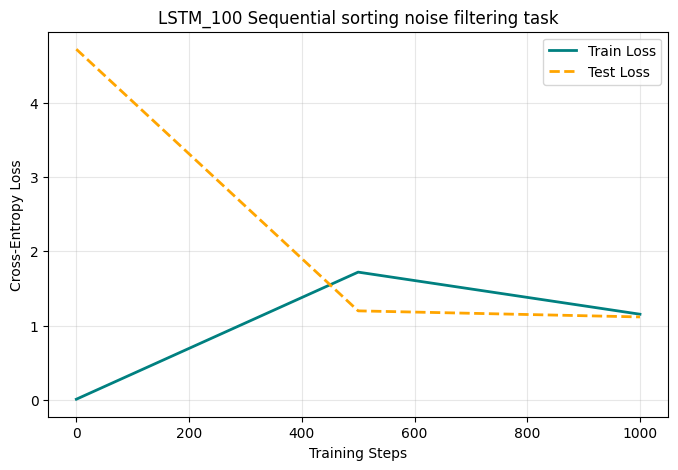

STEP: 1000 | TRAIN LOSS: 1.1542 | TEST LOSS: 1.1176


  0%|          | 0/10 [00:00<?, ?it/s]

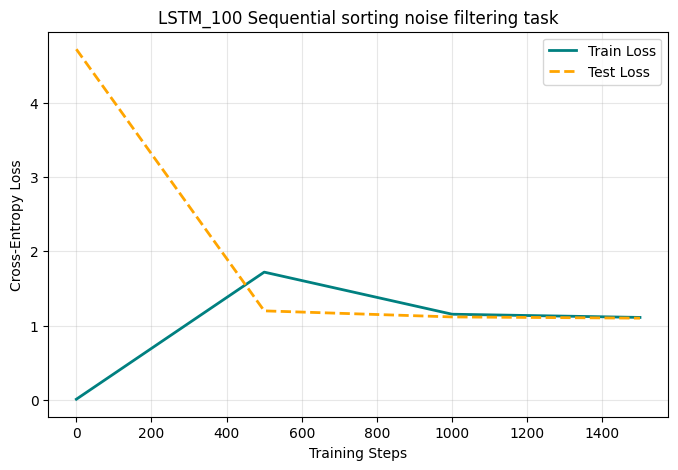

STEP: 1500 | TRAIN LOSS: 1.1110 | TEST LOSS: 1.1012


  0%|          | 0/10 [00:00<?, ?it/s]

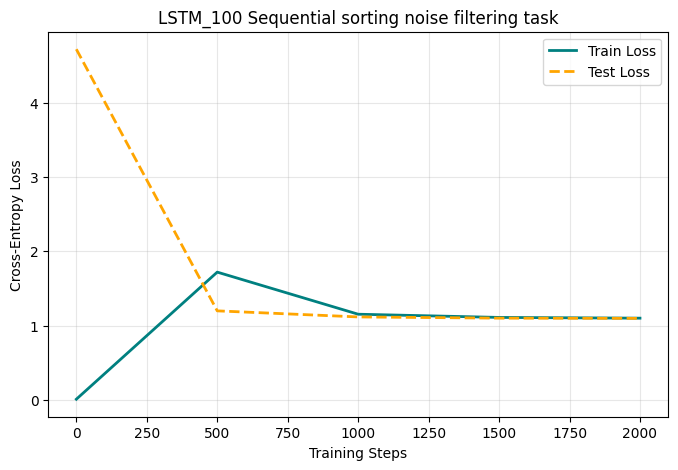

STEP: 2000 | TRAIN LOSS: 1.1010 | TEST LOSS: 1.0985


  0%|          | 0/10 [00:00<?, ?it/s]

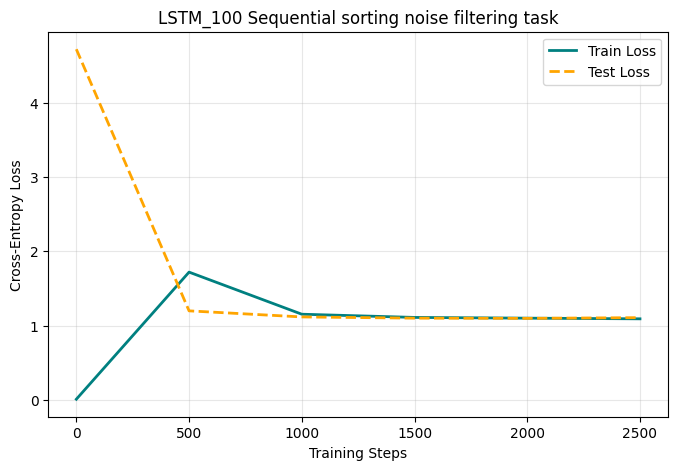

STEP: 2500 | TRAIN LOSS: 1.0921 | TEST LOSS: 1.1079


  0%|          | 0/10 [00:00<?, ?it/s]

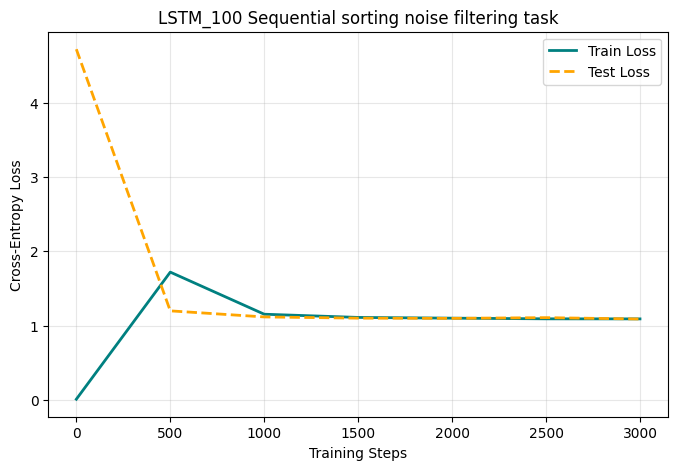

STEP: 3000 | TRAIN LOSS: 1.0913 | TEST LOSS: 1.0895


  0%|          | 0/10 [00:00<?, ?it/s]

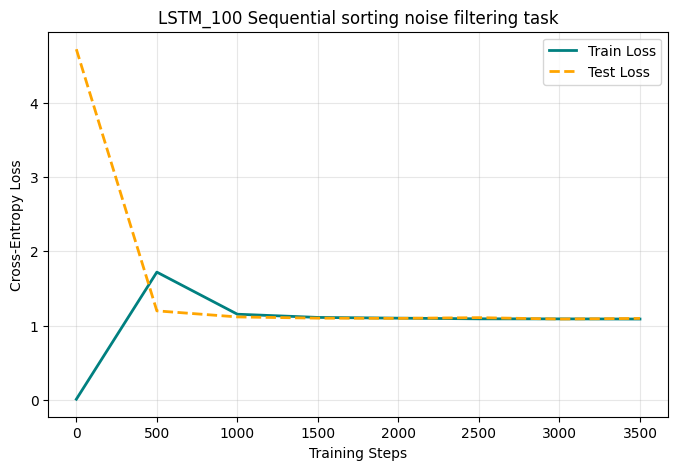

STEP: 3500 | TRAIN LOSS: 1.0892 | TEST LOSS: 1.0977


  0%|          | 0/10 [00:00<?, ?it/s]

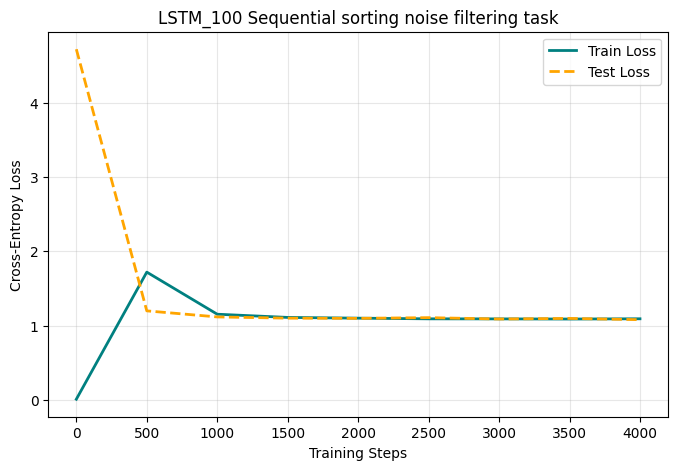

STEP: 4000 | TRAIN LOSS: 1.0928 | TEST LOSS: 1.0806


  0%|          | 0/10 [00:00<?, ?it/s]

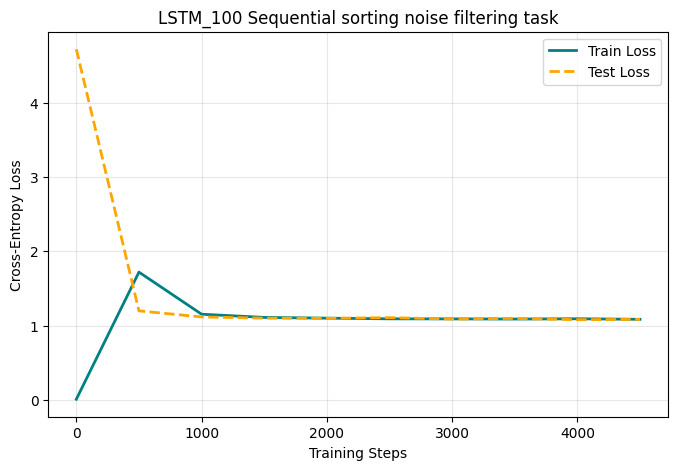

STEP: 4500 | TRAIN LOSS: 1.0857 | TEST LOSS: 1.0848


  0%|          | 0/10 [00:00<?, ?it/s]

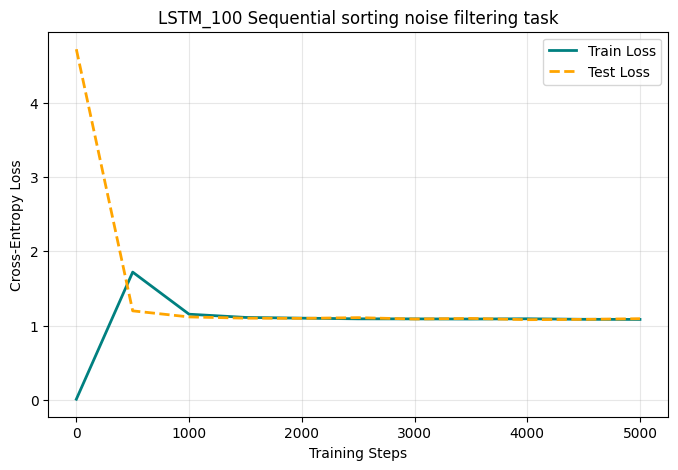

STEP: 5000 | TRAIN LOSS: 1.0839 | TEST LOSS: 1.0941


  0%|          | 0/10 [00:00<?, ?it/s]

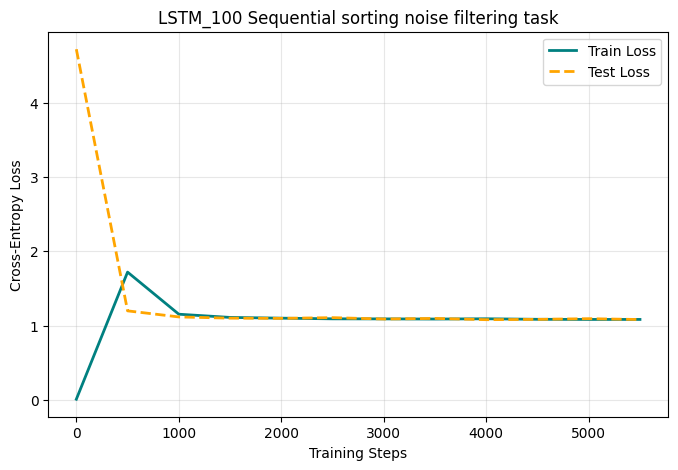

STEP: 5500 | TRAIN LOSS: 1.0839 | TEST LOSS: 1.0829


  0%|          | 0/10 [00:00<?, ?it/s]

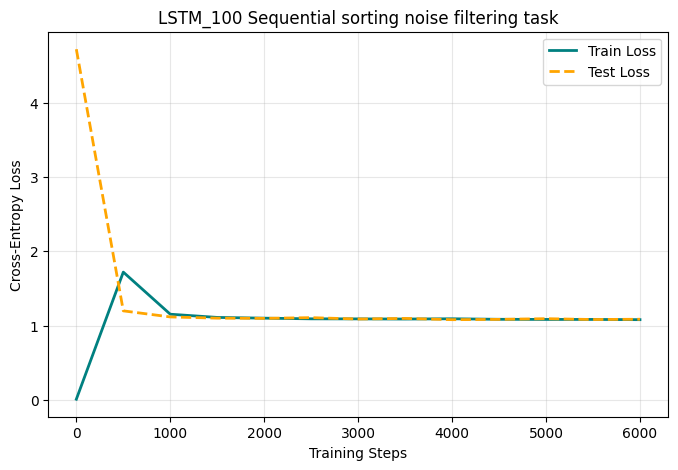

STEP: 6000 | TRAIN LOSS: 1.0808 | TEST LOSS: 1.0866


  0%|          | 0/10 [00:00<?, ?it/s]

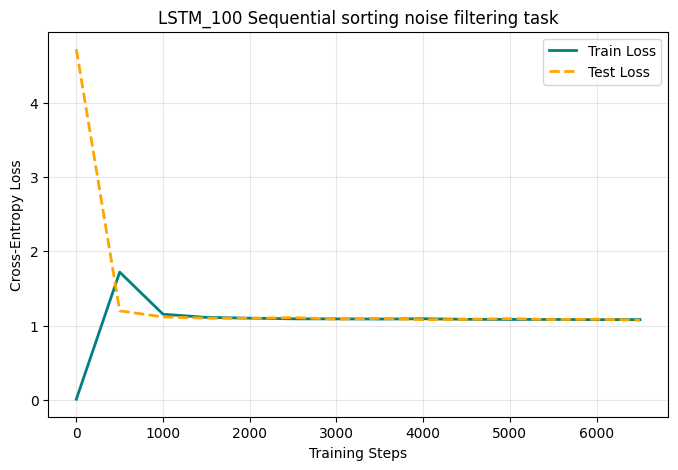

STEP: 6500 | TRAIN LOSS: 1.0818 | TEST LOSS: 1.0731


  0%|          | 0/10 [00:00<?, ?it/s]

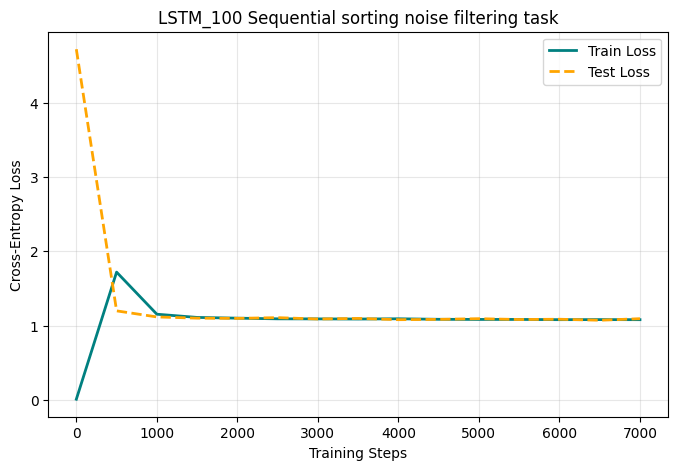

STEP: 7000 | TRAIN LOSS: 1.0806 | TEST LOSS: 1.0939


In [6]:
steps_history = []
train_history = []
test_history = []

run_training_ex3(model=LSTM_model, 
                 batch_size=batch_size, 
                 total_batches=total_batches, 
                 test_batches=test_batches, 
                 copy_size=copy_size,
                 buffer_size=buffer_size, 
                 opt=opt_LSTM, 
                 test_break=500, 
                 model_name="LSTM_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

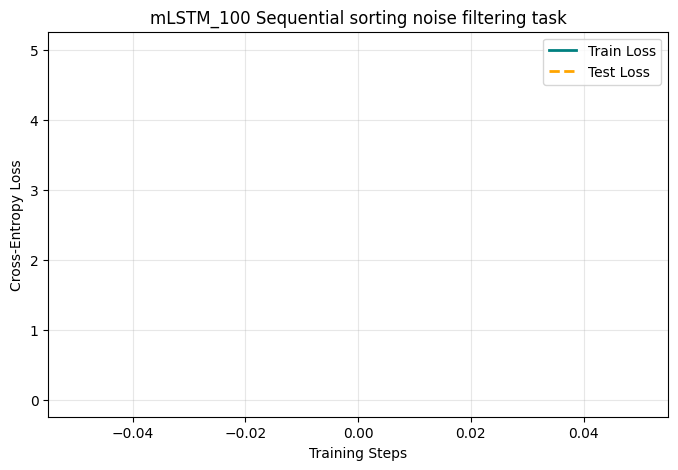

STEP: 0 | TRAIN LOSS: 0.0100 | TEST LOSS: 5.0053


  0%|          | 0/10 [00:00<?, ?it/s]

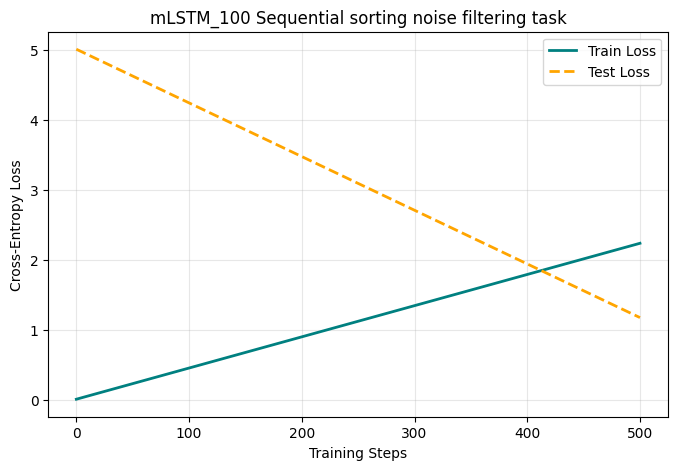

STEP: 500 | TRAIN LOSS: 2.2357 | TEST LOSS: 1.1751


  0%|          | 0/10 [00:00<?, ?it/s]

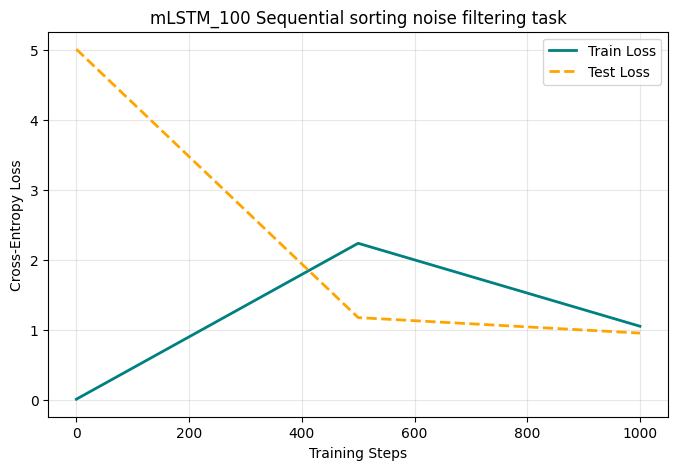

STEP: 1000 | TRAIN LOSS: 1.0515 | TEST LOSS: 0.9537


  0%|          | 0/10 [00:00<?, ?it/s]

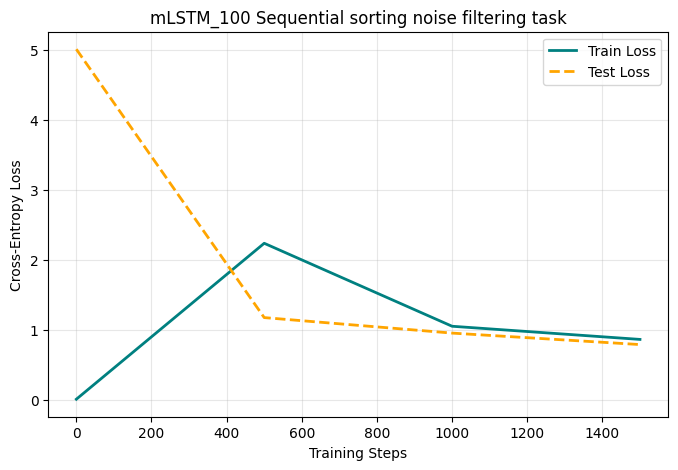

STEP: 1500 | TRAIN LOSS: 0.8637 | TEST LOSS: 0.7901


  0%|          | 0/10 [00:00<?, ?it/s]

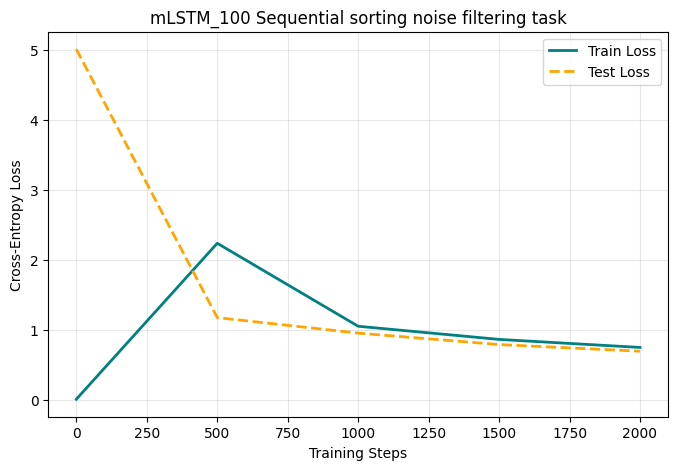

STEP: 2000 | TRAIN LOSS: 0.7491 | TEST LOSS: 0.6952


  0%|          | 0/10 [00:00<?, ?it/s]

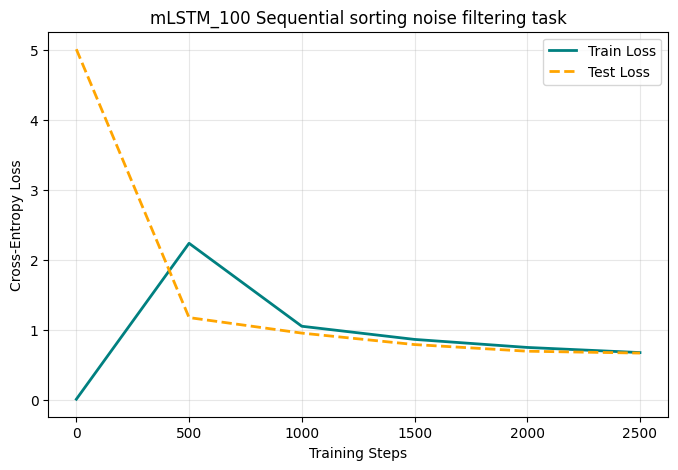

STEP: 2500 | TRAIN LOSS: 0.6757 | TEST LOSS: 0.6685


  0%|          | 0/10 [00:00<?, ?it/s]

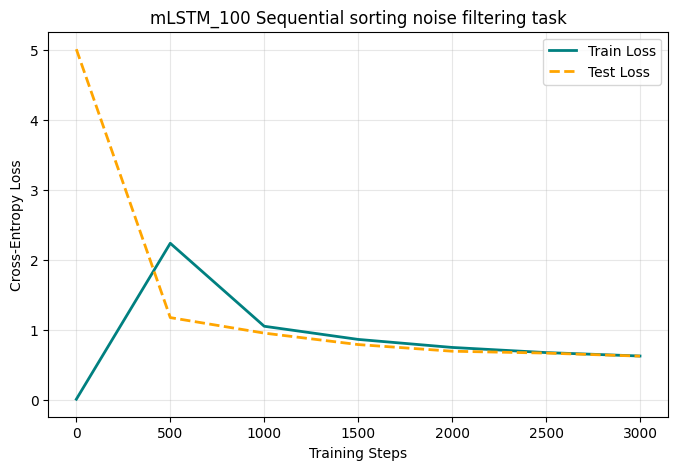

STEP: 3000 | TRAIN LOSS: 0.6266 | TEST LOSS: 0.6251


  0%|          | 0/10 [00:00<?, ?it/s]

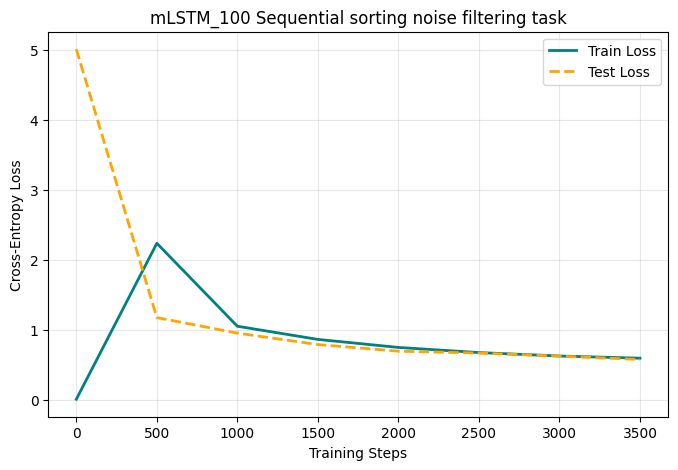

STEP: 3500 | TRAIN LOSS: 0.5956 | TEST LOSS: 0.5771


  0%|          | 0/10 [00:00<?, ?it/s]

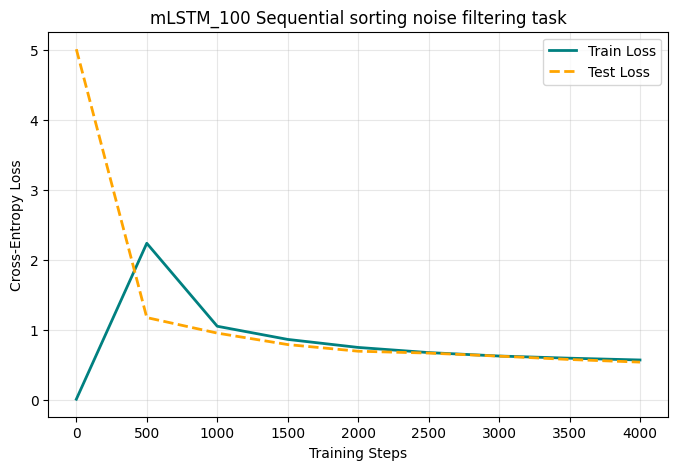

STEP: 4000 | TRAIN LOSS: 0.5700 | TEST LOSS: 0.5396


  0%|          | 0/10 [00:00<?, ?it/s]

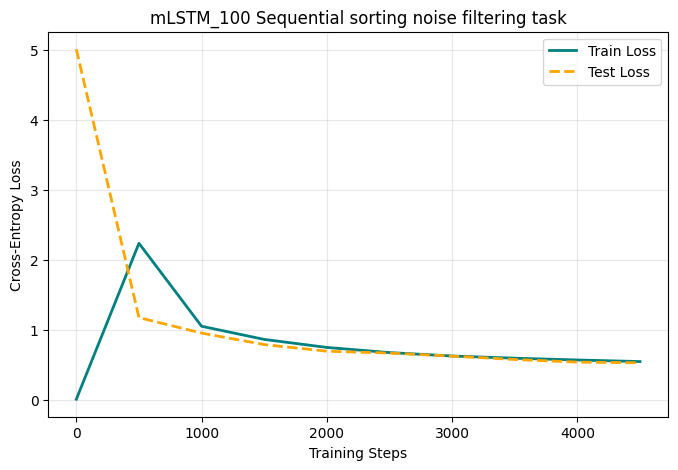

STEP: 4500 | TRAIN LOSS: 0.5476 | TEST LOSS: 0.5304


  0%|          | 0/10 [00:00<?, ?it/s]

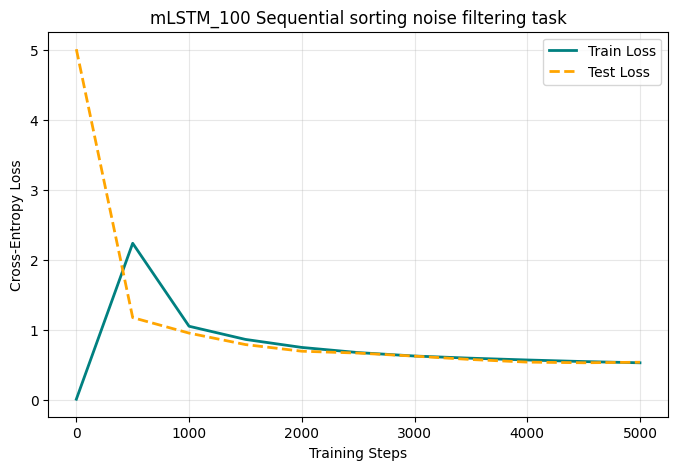

STEP: 5000 | TRAIN LOSS: 0.5300 | TEST LOSS: 0.5379


  0%|          | 0/10 [00:00<?, ?it/s]

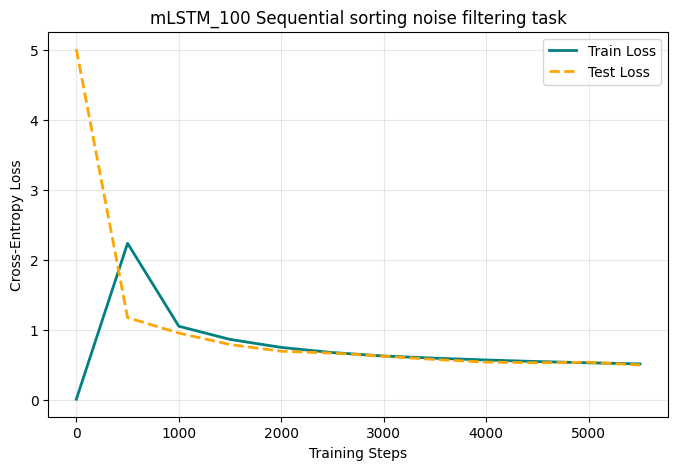

STEP: 5500 | TRAIN LOSS: 0.5140 | TEST LOSS: 0.4993


  0%|          | 0/10 [00:00<?, ?it/s]

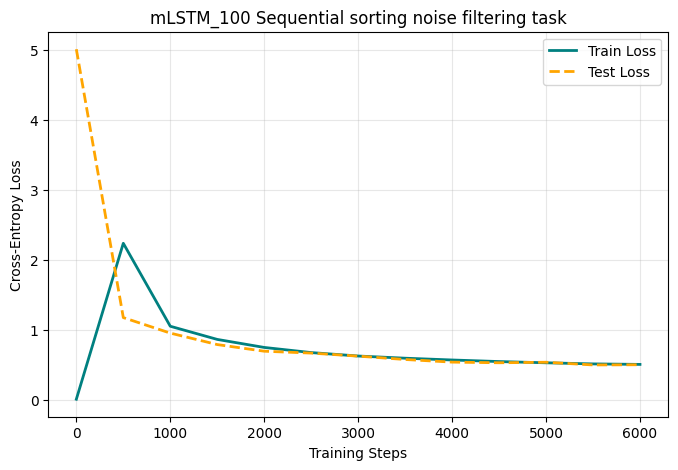

STEP: 6000 | TRAIN LOSS: 0.5070 | TEST LOSS: 0.5020


  0%|          | 0/10 [00:00<?, ?it/s]

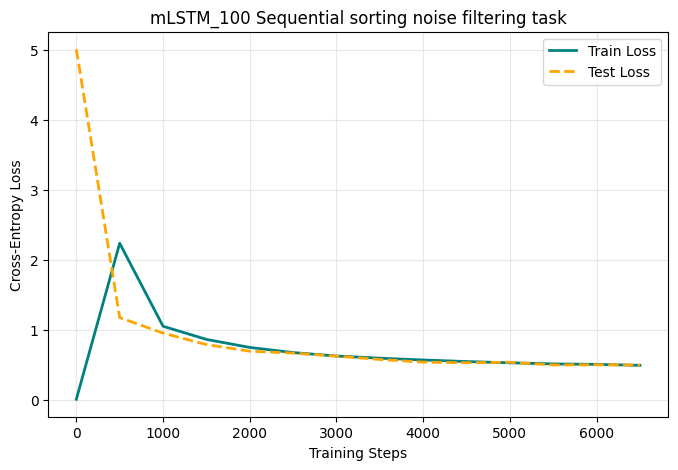

STEP: 6500 | TRAIN LOSS: 0.4941 | TEST LOSS: 0.4983


  0%|          | 0/10 [00:00<?, ?it/s]

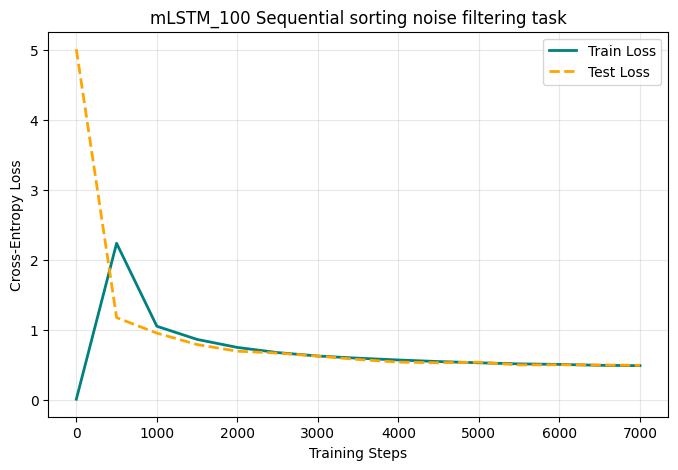

STEP: 7000 | TRAIN LOSS: 0.4891 | TEST LOSS: 0.4940


In [5]:
steps_history = []
train_history = []
test_history = []

run_training_ex3(model=mLSTM_model, 
                 batch_size=batch_size, 
                 total_batches=total_batches, 
                 test_batches=test_batches, 
                 copy_size=copy_size,
                 buffer_size=buffer_size, 
                 opt=opt_mLSTM, 
                 test_break=500, 
                 model_name="mLSTM_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

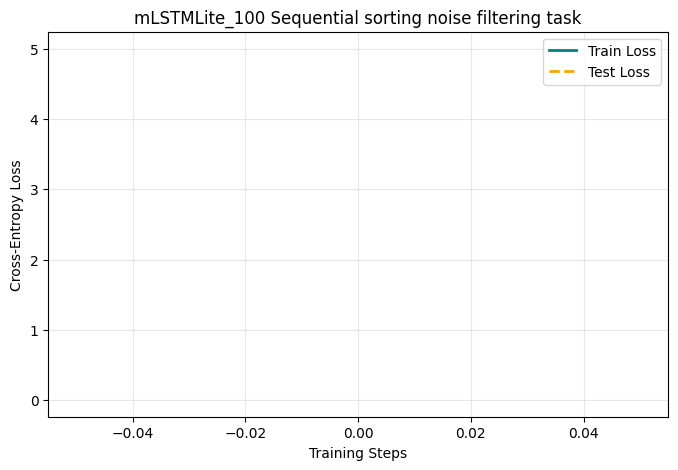

STEP: 0 | TRAIN LOSS: 0.0100 | TEST LOSS: 4.9969


  0%|          | 0/10 [00:00<?, ?it/s]

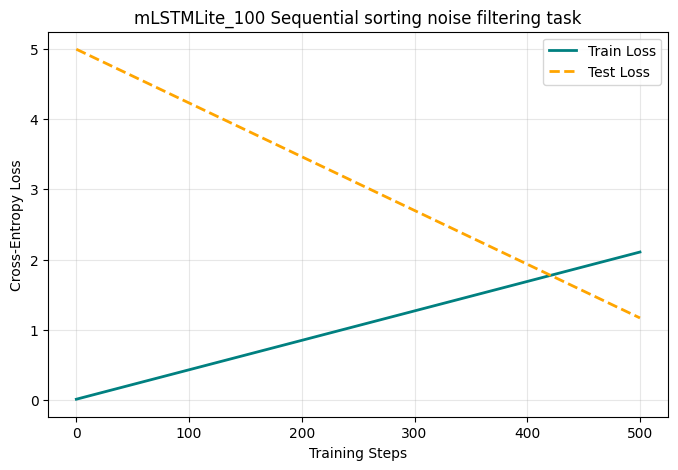

STEP: 500 | TRAIN LOSS: 2.1073 | TEST LOSS: 1.1679


  0%|          | 0/10 [00:00<?, ?it/s]

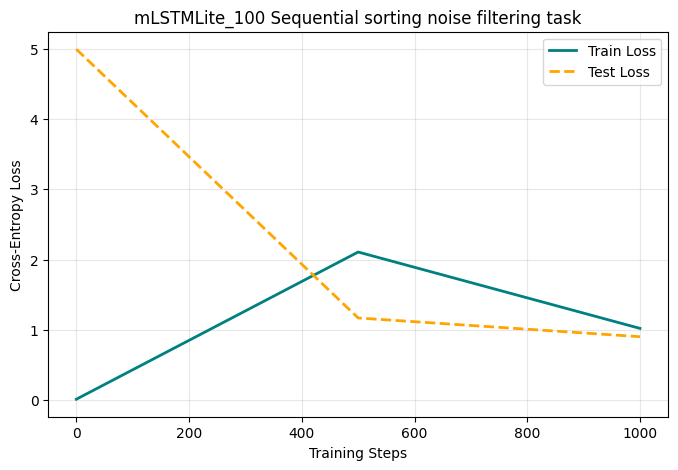

STEP: 1000 | TRAIN LOSS: 1.0192 | TEST LOSS: 0.9007


  0%|          | 0/10 [00:00<?, ?it/s]

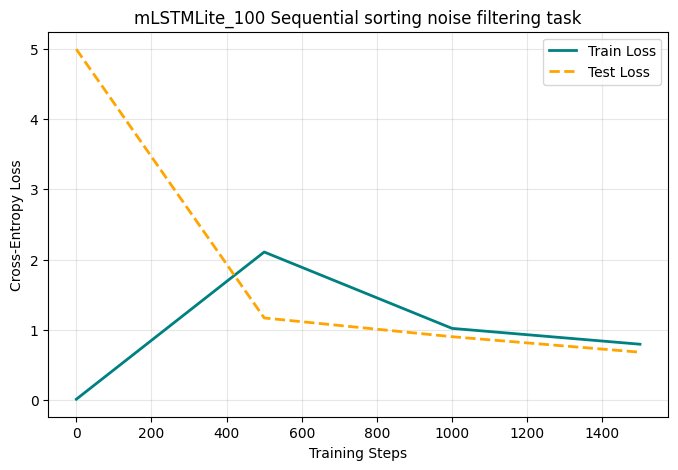

STEP: 1500 | TRAIN LOSS: 0.7937 | TEST LOSS: 0.6799


  0%|          | 0/10 [00:00<?, ?it/s]

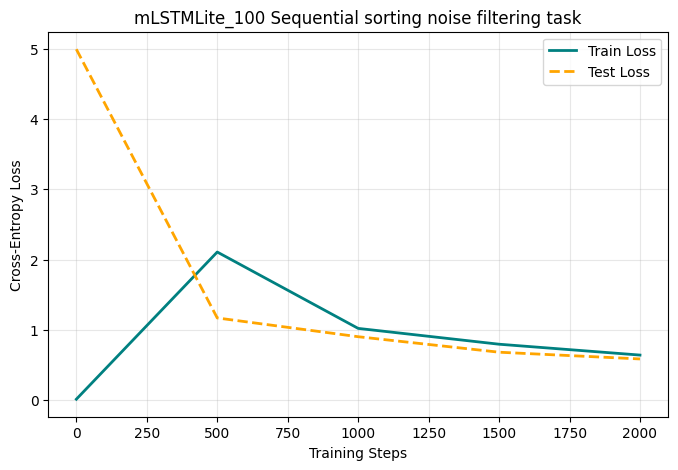

STEP: 2000 | TRAIN LOSS: 0.6390 | TEST LOSS: 0.5838


  0%|          | 0/10 [00:00<?, ?it/s]

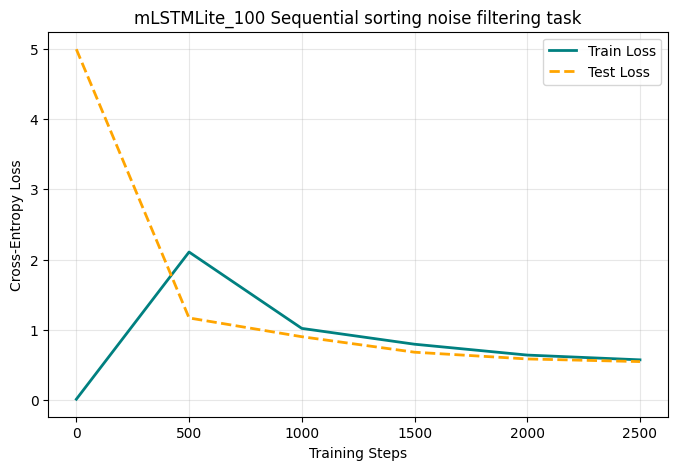

STEP: 2500 | TRAIN LOSS: 0.5712 | TEST LOSS: 0.5462


  0%|          | 0/10 [00:00<?, ?it/s]

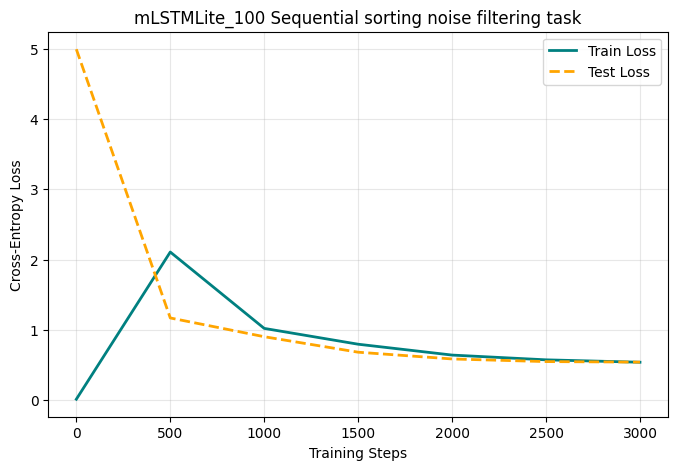

STEP: 3000 | TRAIN LOSS: 0.5370 | TEST LOSS: 0.5388


  0%|          | 0/10 [00:00<?, ?it/s]

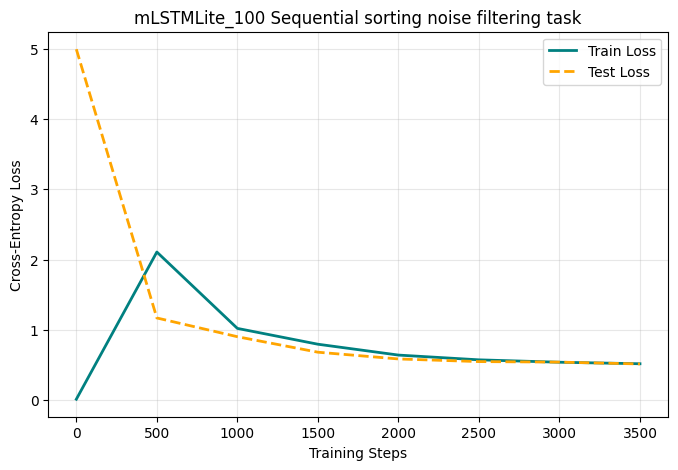

STEP: 3500 | TRAIN LOSS: 0.5154 | TEST LOSS: 0.5125


  0%|          | 0/10 [00:00<?, ?it/s]

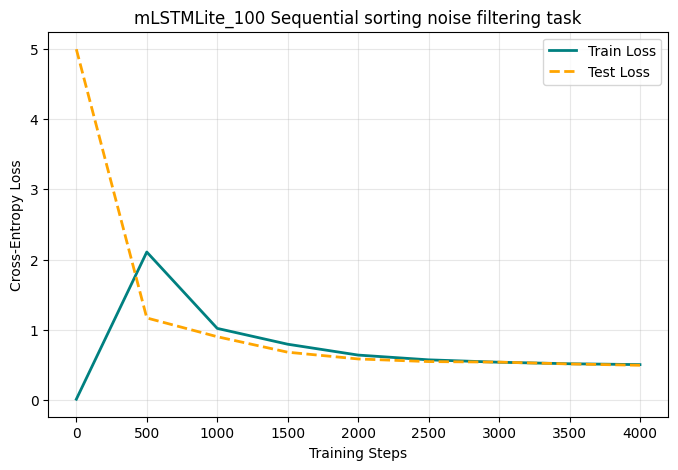

STEP: 4000 | TRAIN LOSS: 0.5032 | TEST LOSS: 0.4937


  0%|          | 0/10 [00:00<?, ?it/s]

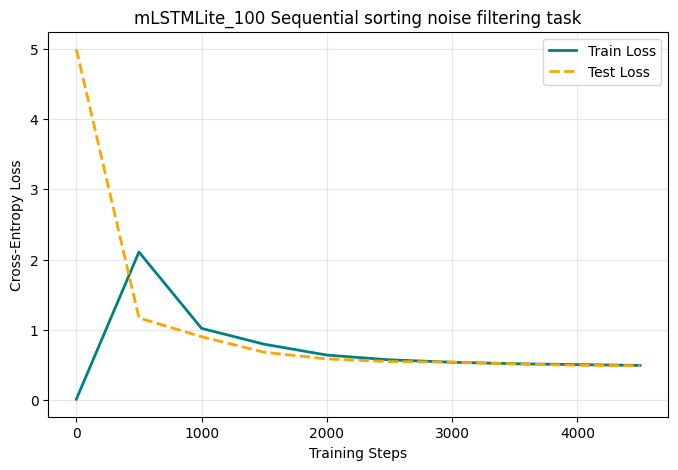

STEP: 4500 | TRAIN LOSS: 0.4918 | TEST LOSS: 0.4869


  0%|          | 0/10 [00:00<?, ?it/s]

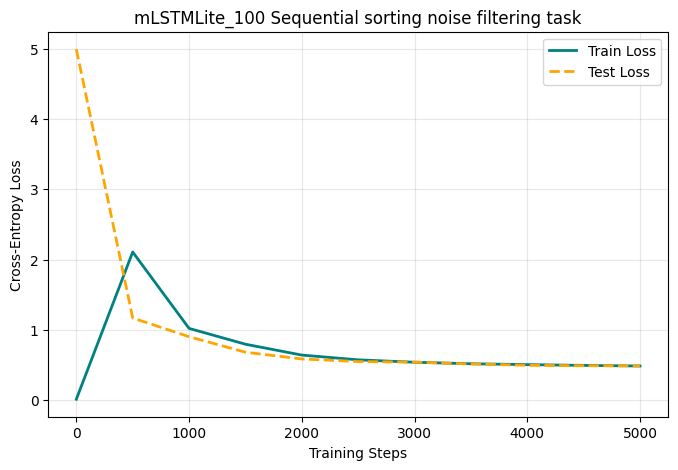

STEP: 5000 | TRAIN LOSS: 0.4833 | TEST LOSS: 0.4867


  0%|          | 0/10 [00:00<?, ?it/s]

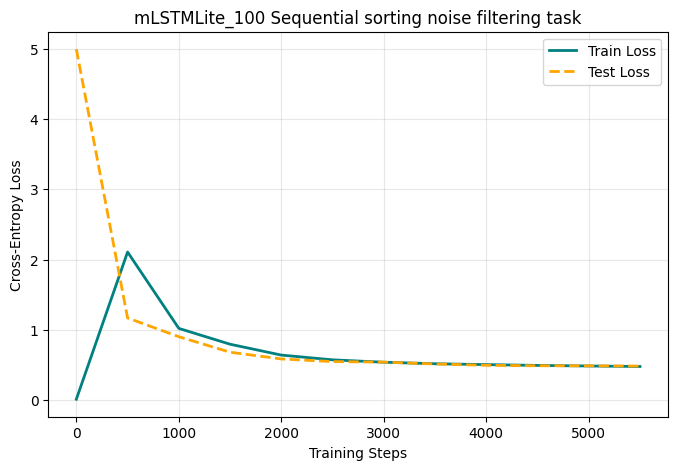

STEP: 5500 | TRAIN LOSS: 0.4763 | TEST LOSS: 0.4819


  0%|          | 0/10 [00:00<?, ?it/s]

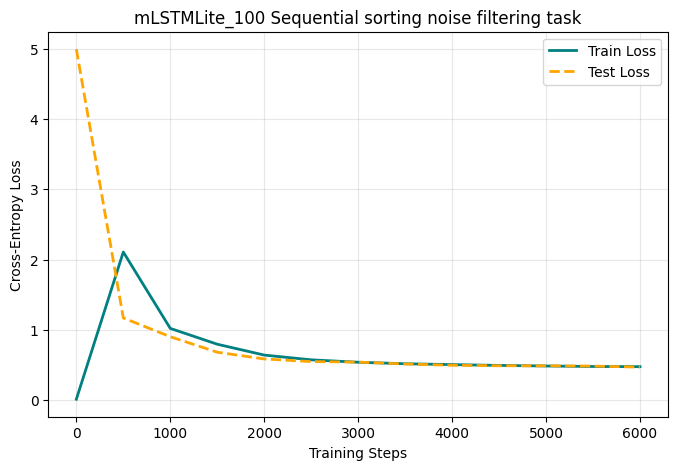

STEP: 6000 | TRAIN LOSS: 0.4739 | TEST LOSS: 0.4672


  0%|          | 0/10 [00:00<?, ?it/s]

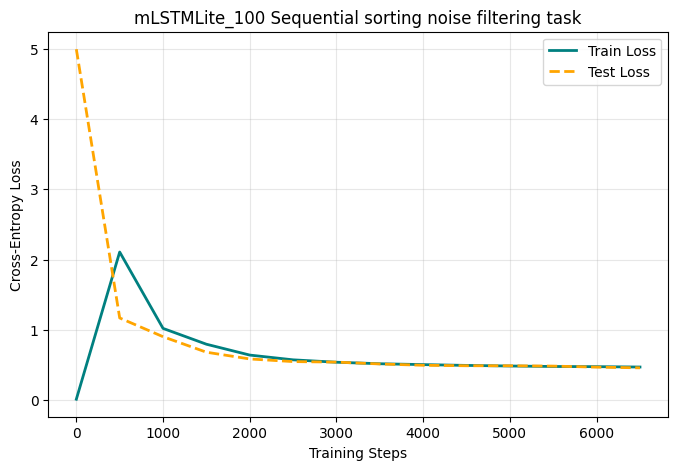

STEP: 6500 | TRAIN LOSS: 0.4687 | TEST LOSS: 0.4572


  0%|          | 0/10 [00:00<?, ?it/s]

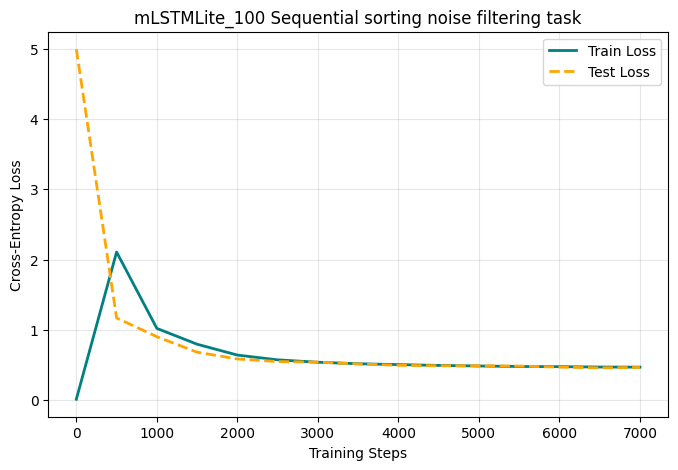

STEP: 7000 | TRAIN LOSS: 0.4671 | TEST LOSS: 0.4630


In [6]:
steps_history = []
train_history = []
test_history = []

run_training_ex3(model=mLSTMLite_model, 
                 batch_size=batch_size, 
                 total_batches=total_batches, 
                 test_batches=test_batches, 
                 copy_size=copy_size,
                 buffer_size=buffer_size, 
                 opt=opt_mLSTMLite, 
                 test_break=500, 
                 model_name="mLSTMLite_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

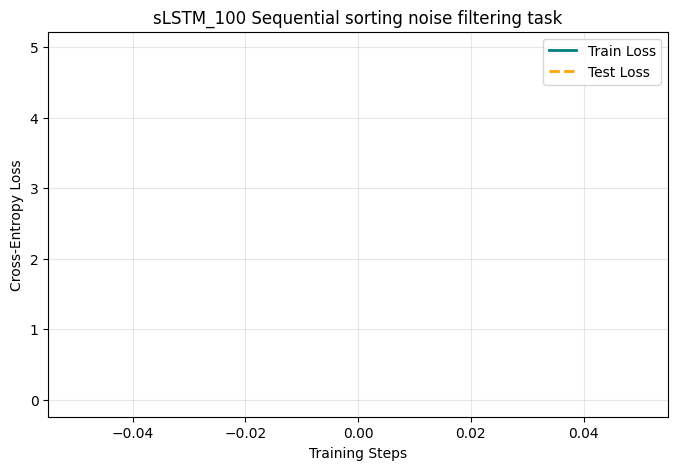

STEP: 0 | TRAIN LOSS: 0.0100 | TEST LOSS: 4.9671


  0%|          | 0/10 [00:00<?, ?it/s]

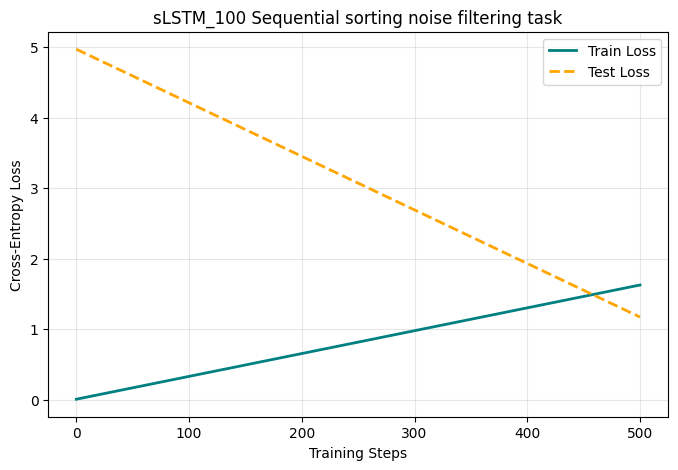

STEP: 500 | TRAIN LOSS: 1.6276 | TEST LOSS: 1.1740


  0%|          | 0/10 [00:00<?, ?it/s]

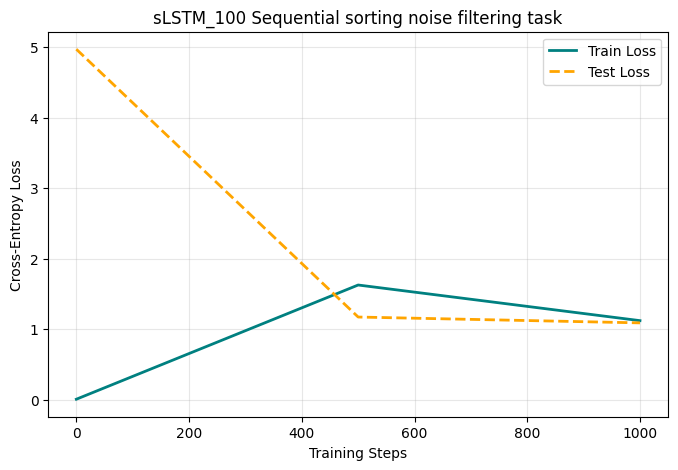

STEP: 1000 | TRAIN LOSS: 1.1229 | TEST LOSS: 1.0913


  0%|          | 0/10 [00:00<?, ?it/s]

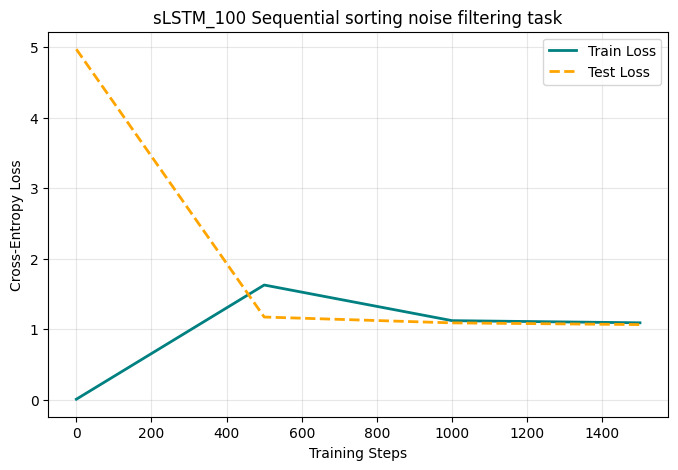

STEP: 1500 | TRAIN LOSS: 1.0923 | TEST LOSS: 1.0669


  0%|          | 0/10 [00:00<?, ?it/s]

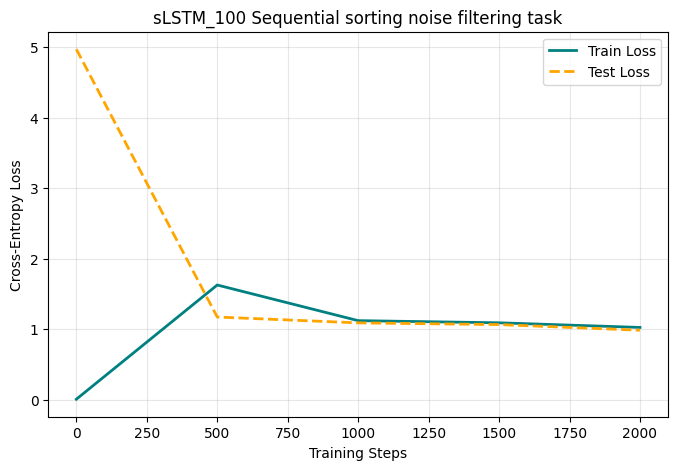

STEP: 2000 | TRAIN LOSS: 1.0267 | TEST LOSS: 0.9872


  0%|          | 0/10 [00:00<?, ?it/s]

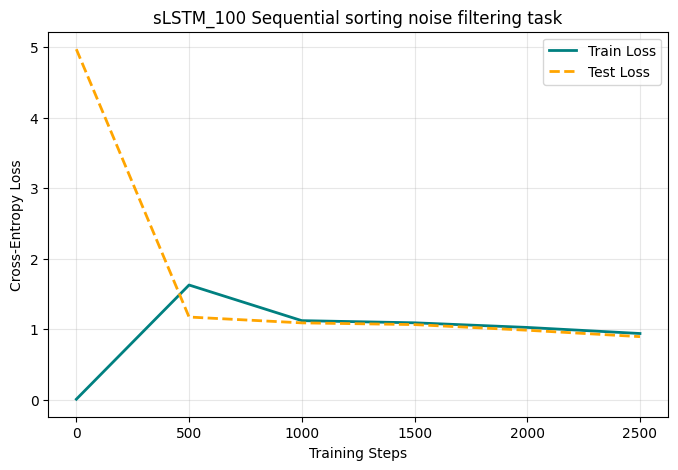

STEP: 2500 | TRAIN LOSS: 0.9408 | TEST LOSS: 0.8962


  0%|          | 0/10 [00:00<?, ?it/s]

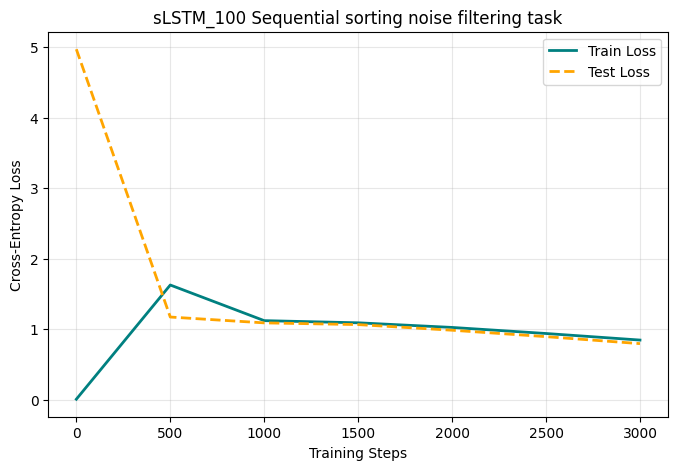

STEP: 3000 | TRAIN LOSS: 0.8479 | TEST LOSS: 0.7973


  0%|          | 0/10 [00:00<?, ?it/s]

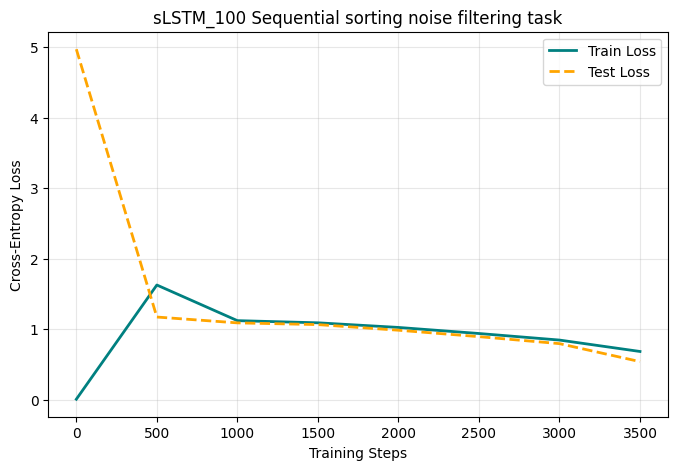

STEP: 3500 | TRAIN LOSS: 0.6862 | TEST LOSS: 0.5425


  0%|          | 0/10 [00:00<?, ?it/s]

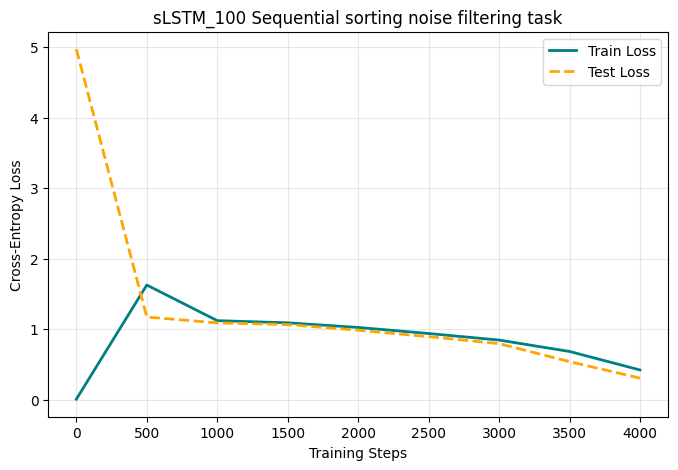

STEP: 4000 | TRAIN LOSS: 0.4245 | TEST LOSS: 0.3084


  0%|          | 0/10 [00:00<?, ?it/s]

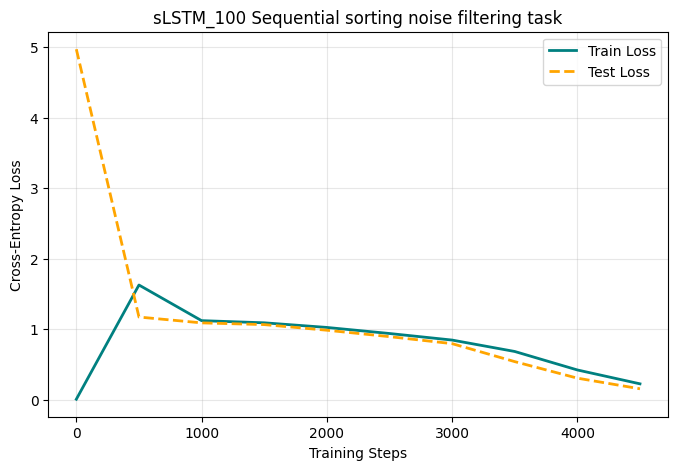

STEP: 4500 | TRAIN LOSS: 0.2280 | TEST LOSS: 0.1577


  0%|          | 0/10 [00:00<?, ?it/s]

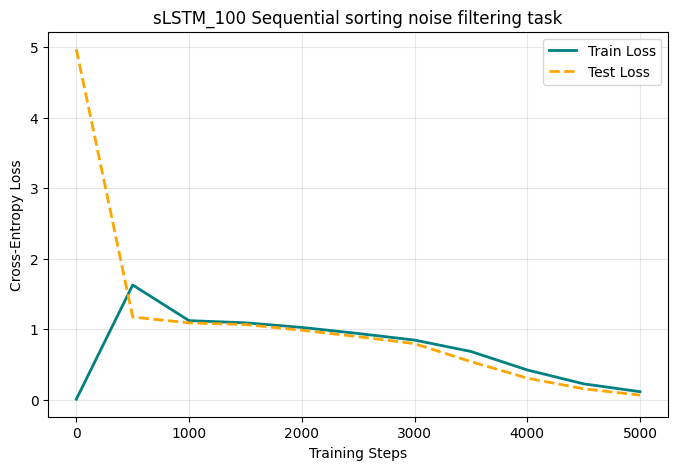

STEP: 5000 | TRAIN LOSS: 0.1166 | TEST LOSS: 0.0681


  0%|          | 0/10 [00:00<?, ?it/s]

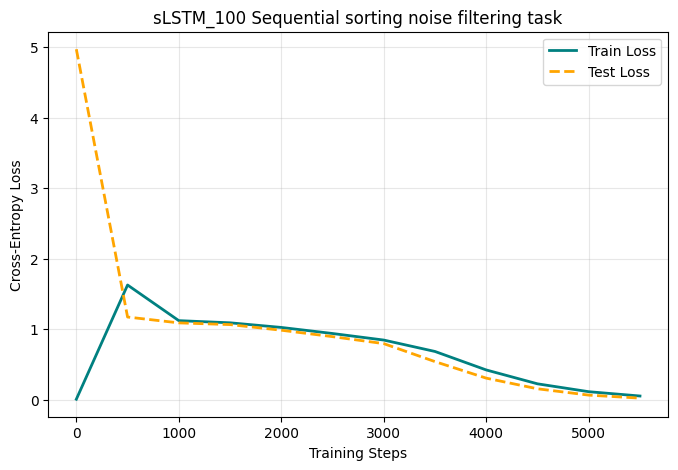

STEP: 5500 | TRAIN LOSS: 0.0555 | TEST LOSS: 0.0255


  0%|          | 0/10 [00:00<?, ?it/s]

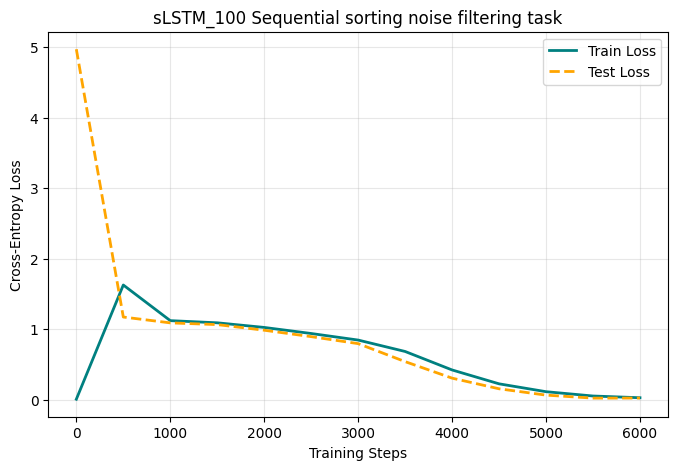

STEP: 6000 | TRAIN LOSS: 0.0311 | TEST LOSS: 0.0266


  0%|          | 0/10 [00:00<?, ?it/s]

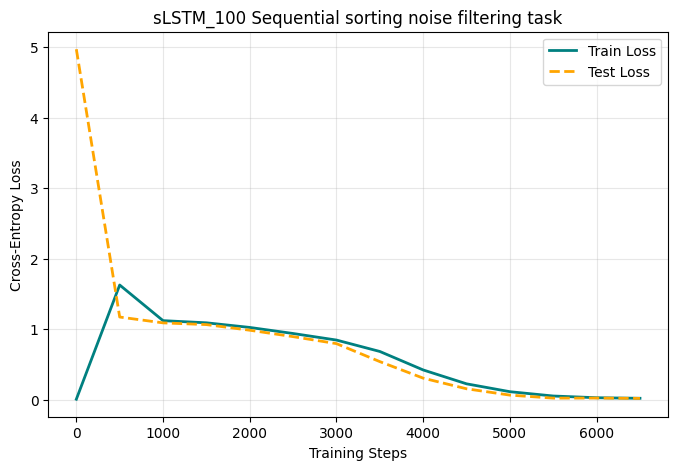

STEP: 6500 | TRAIN LOSS: 0.0232 | TEST LOSS: 0.0218


  0%|          | 0/10 [00:00<?, ?it/s]

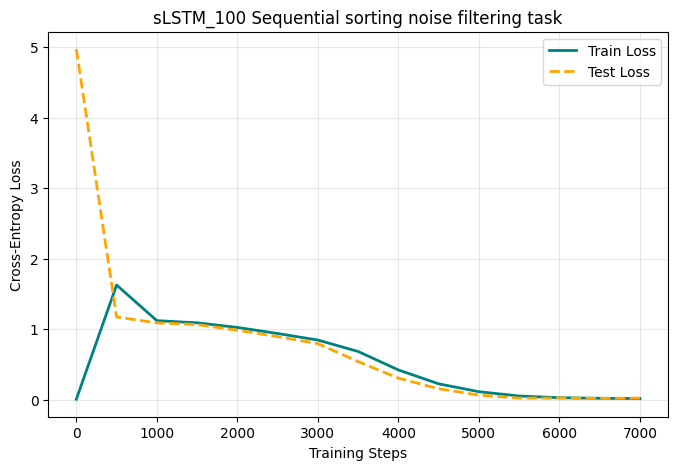

STEP: 7000 | TRAIN LOSS: 0.0193 | TEST LOSS: 0.0259


In [ ]:
steps_history = []
train_history = []
test_history = []

run_training_ex3(sLSTM_model, 
                 batch_size, 
                 total_batches, 
                 test_batches, 
                 copy_size, 
                 buffer_size, 
                 opt_sLSTM, 
                 test_break=500, 
                 model_name="sLSTM_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

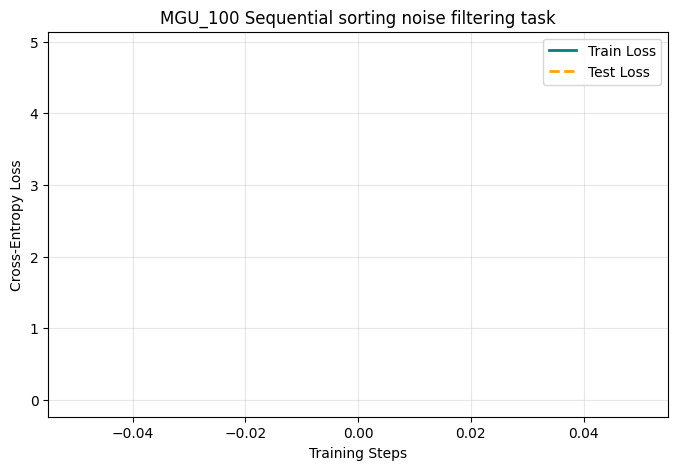

STEP: 0 | TRAIN LOSS: 0.0100 | TEST LOSS: 4.8955


  0%|          | 0/10 [00:00<?, ?it/s]

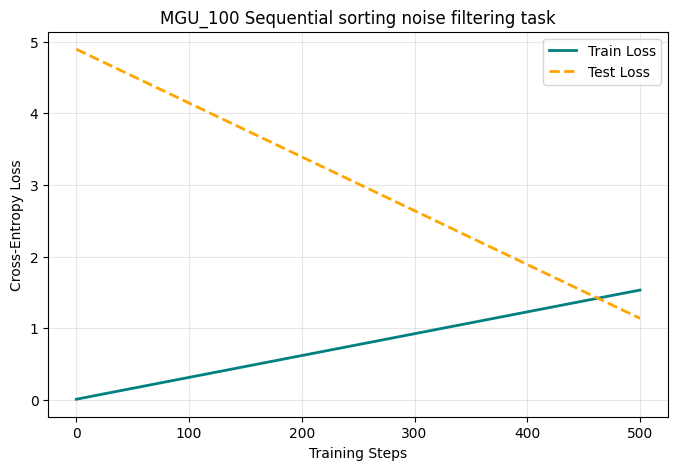

STEP: 500 | TRAIN LOSS: 1.5339 | TEST LOSS: 1.1388


  0%|          | 0/10 [00:00<?, ?it/s]

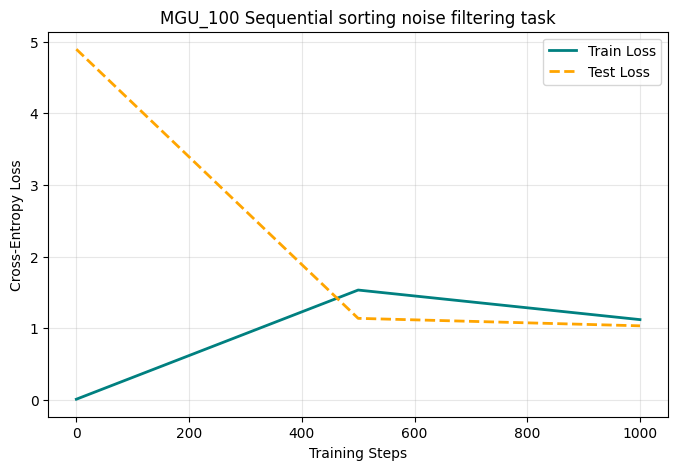

STEP: 1000 | TRAIN LOSS: 1.1211 | TEST LOSS: 1.0345


  0%|          | 0/10 [00:00<?, ?it/s]

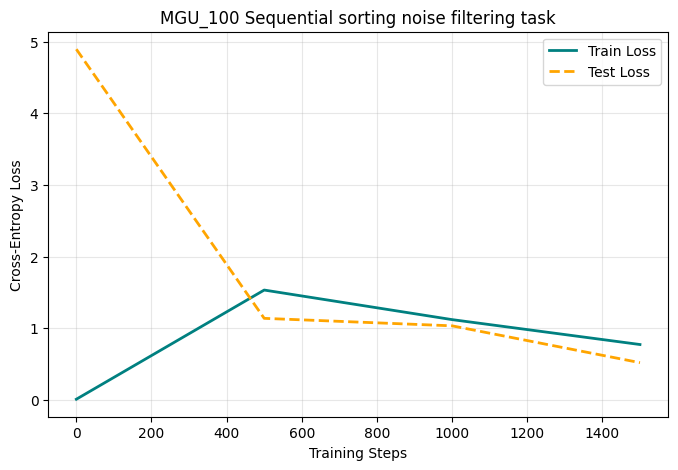

STEP: 1500 | TRAIN LOSS: 0.7735 | TEST LOSS: 0.5201


  0%|          | 0/10 [00:00<?, ?it/s]

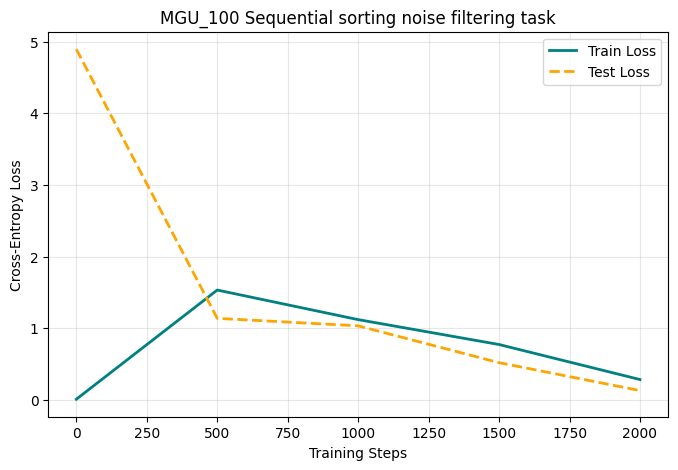

STEP: 2000 | TRAIN LOSS: 0.2846 | TEST LOSS: 0.1307


  0%|          | 0/10 [00:00<?, ?it/s]

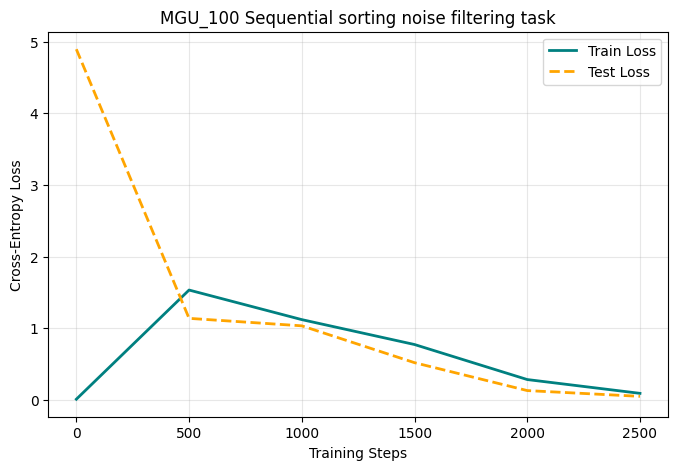

STEP: 2500 | TRAIN LOSS: 0.0919 | TEST LOSS: 0.0500


  0%|          | 0/10 [00:00<?, ?it/s]

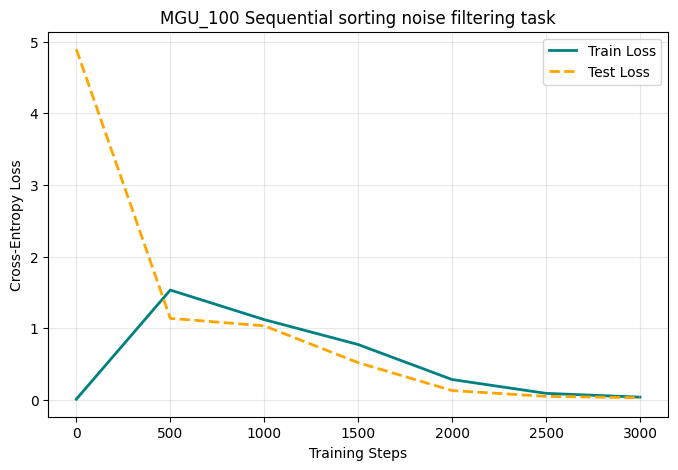

STEP: 3000 | TRAIN LOSS: 0.0389 | TEST LOSS: 0.0304


  0%|          | 0/10 [00:00<?, ?it/s]

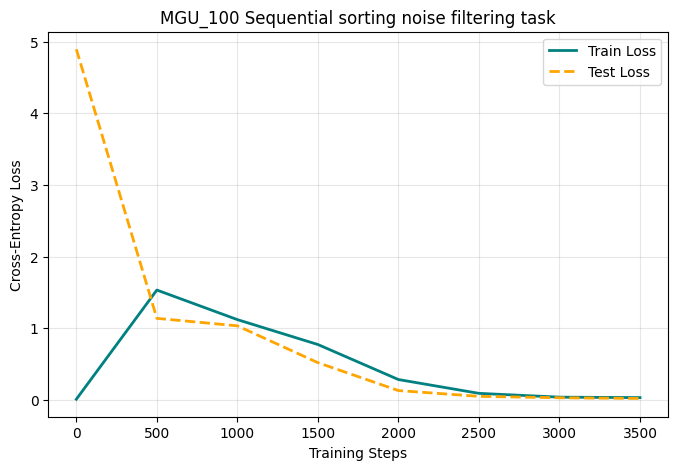

STEP: 3500 | TRAIN LOSS: 0.0325 | TEST LOSS: 0.0206


  0%|          | 0/10 [00:00<?, ?it/s]

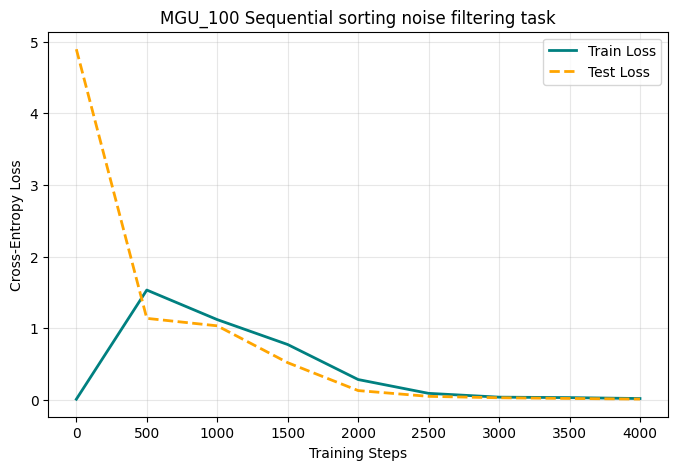

STEP: 4000 | TRAIN LOSS: 0.0196 | TEST LOSS: 0.0116


  0%|          | 0/10 [00:00<?, ?it/s]

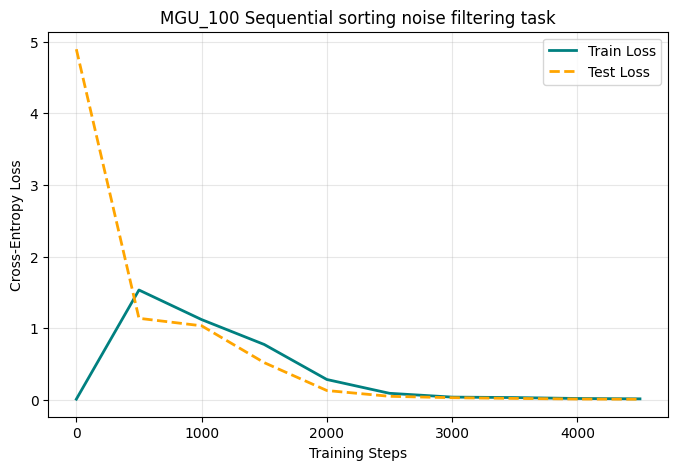

STEP: 4500 | TRAIN LOSS: 0.0147 | TEST LOSS: 0.0093


  0%|          | 0/10 [00:00<?, ?it/s]

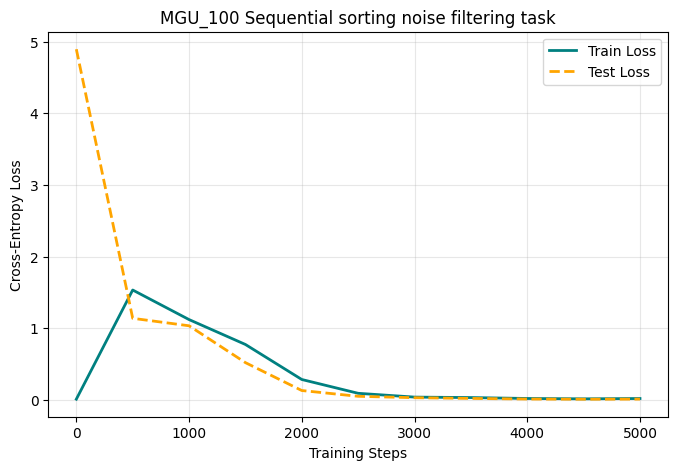

STEP: 5000 | TRAIN LOSS: 0.0192 | TEST LOSS: 0.0107


  0%|          | 0/10 [00:00<?, ?it/s]

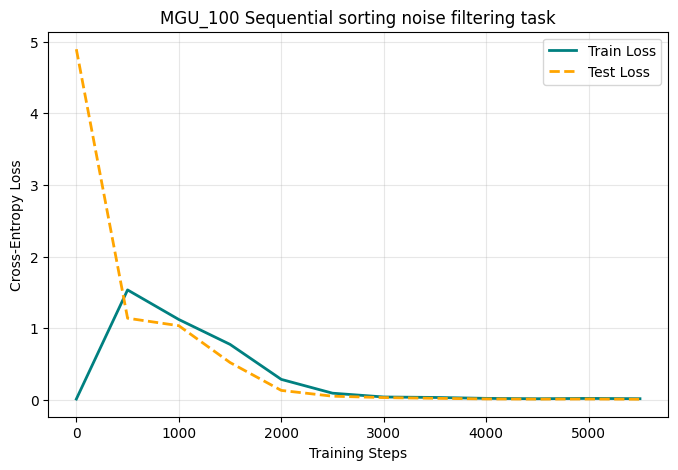

STEP: 5500 | TRAIN LOSS: 0.0150 | TEST LOSS: 0.0077


  0%|          | 0/10 [00:00<?, ?it/s]

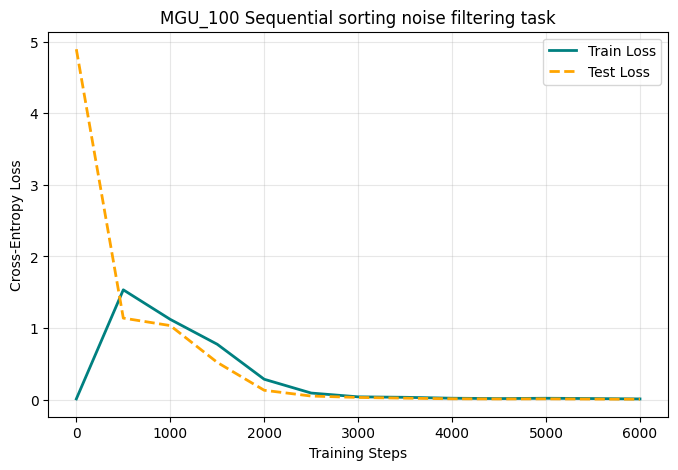

STEP: 6000 | TRAIN LOSS: 0.0099 | TEST LOSS: 0.0057


  0%|          | 0/10 [00:00<?, ?it/s]

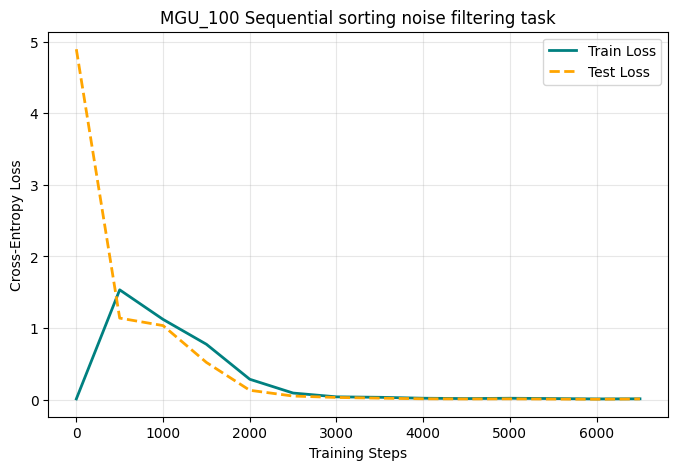

STEP: 6500 | TRAIN LOSS: 0.0117 | TEST LOSS: 0.0095


  0%|          | 0/10 [00:00<?, ?it/s]

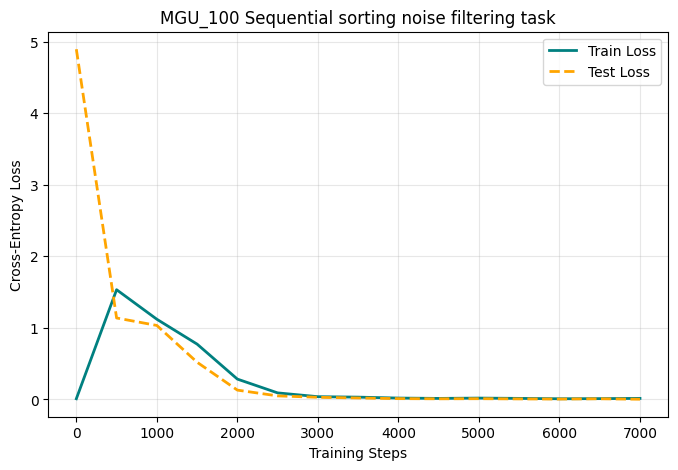

STEP: 7000 | TRAIN LOSS: 0.0151 | TEST LOSS: 0.0034


In [6]:
steps_history = []
train_history = []
test_history = []

run_training_ex3(MGU_model, 
                 batch_size, 
                 total_batches, 
                 test_batches, 
                 copy_size, 
                 buffer_size, 
                 opt_MGU, 
                 test_break=500, 
                 model_name="MGU_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

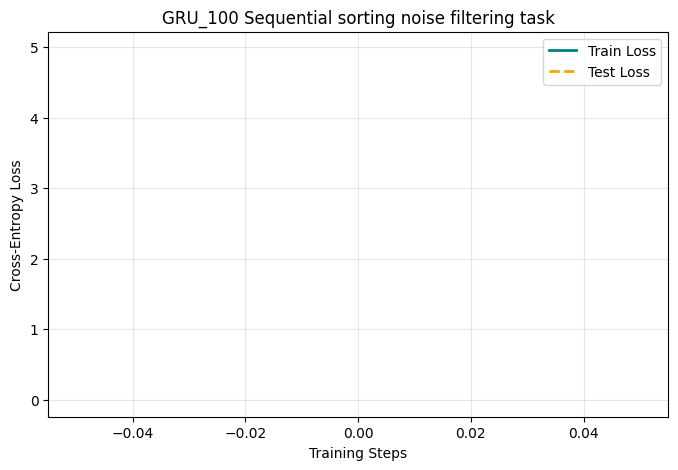

STEP: 0 | TRAIN LOSS: 0.0100 | TEST LOSS: 4.9685


  0%|          | 0/10 [00:00<?, ?it/s]

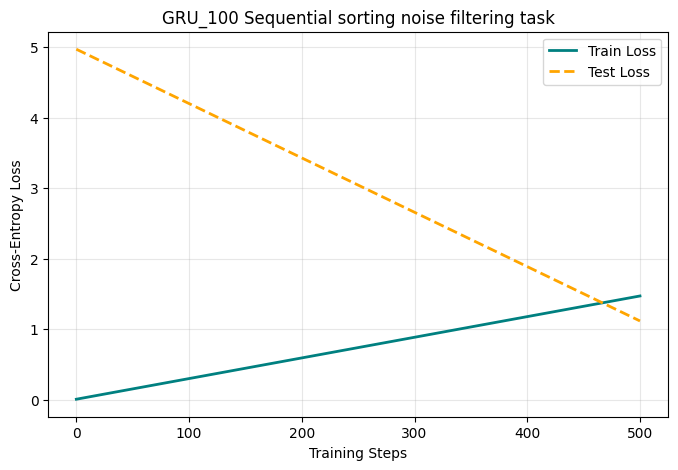

STEP: 500 | TRAIN LOSS: 1.4728 | TEST LOSS: 1.1187


  0%|          | 0/10 [00:00<?, ?it/s]

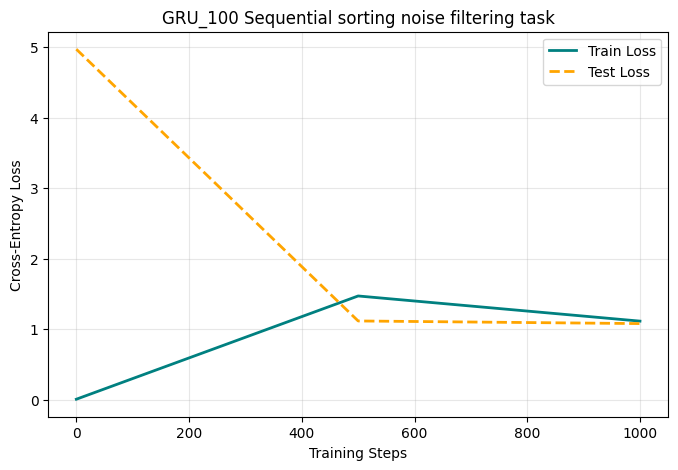

STEP: 1000 | TRAIN LOSS: 1.1164 | TEST LOSS: 1.0816


  0%|          | 0/10 [00:00<?, ?it/s]

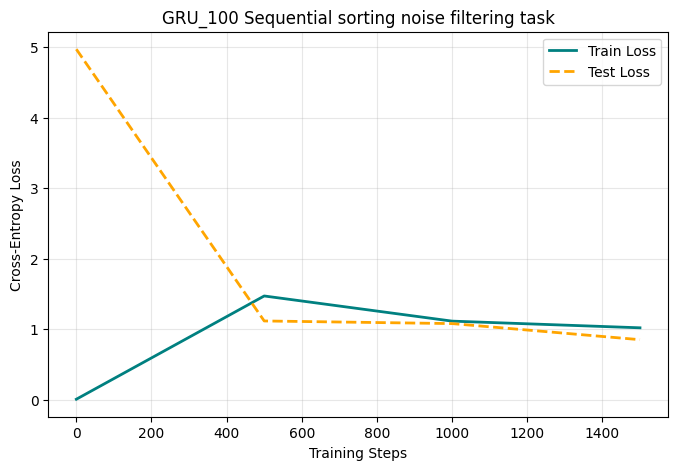

STEP: 1500 | TRAIN LOSS: 1.0217 | TEST LOSS: 0.8535


  0%|          | 0/10 [00:00<?, ?it/s]

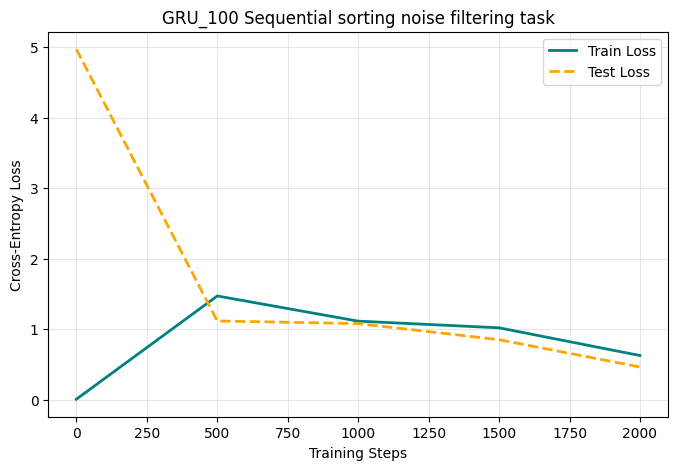

STEP: 2000 | TRAIN LOSS: 0.6288 | TEST LOSS: 0.4665


  0%|          | 0/10 [00:00<?, ?it/s]

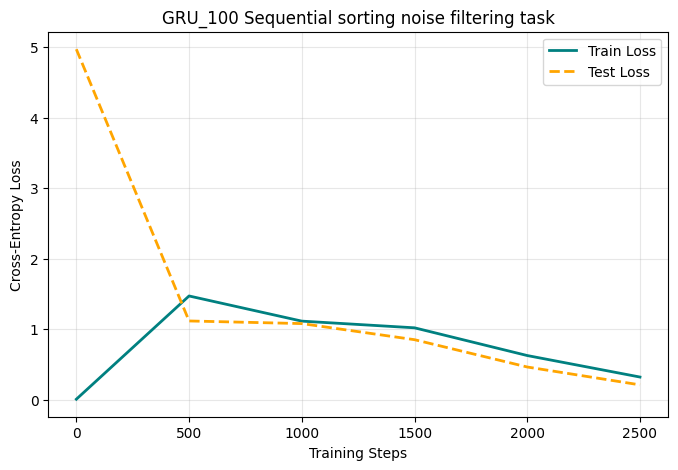

STEP: 2500 | TRAIN LOSS: 0.3242 | TEST LOSS: 0.2134


  0%|          | 0/10 [00:00<?, ?it/s]

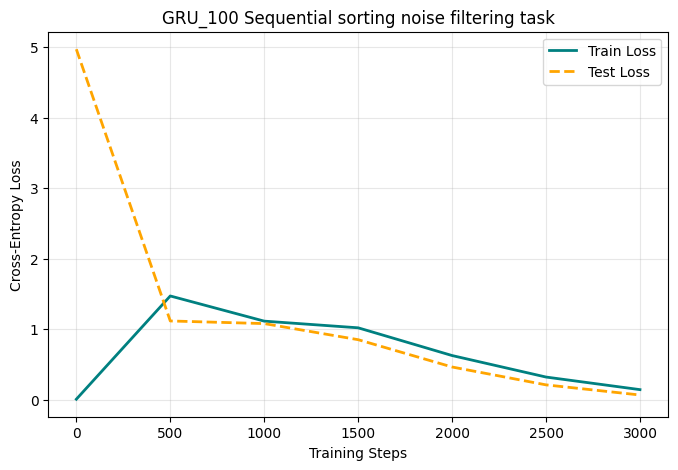

STEP: 3000 | TRAIN LOSS: 0.1458 | TEST LOSS: 0.0697


  0%|          | 0/10 [00:00<?, ?it/s]

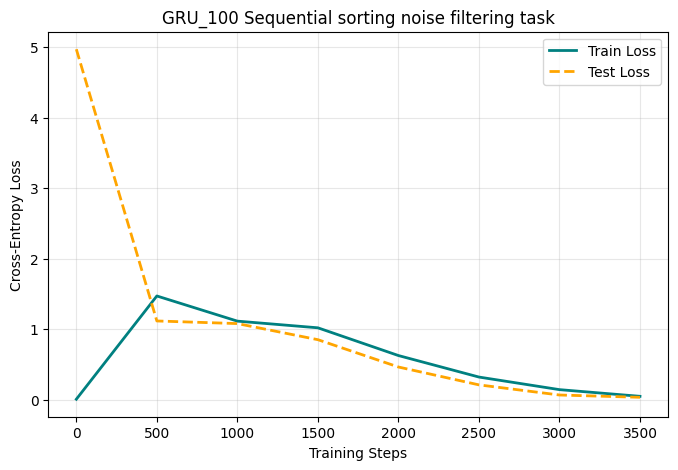

STEP: 3500 | TRAIN LOSS: 0.0511 | TEST LOSS: 0.0373


  0%|          | 0/10 [00:00<?, ?it/s]

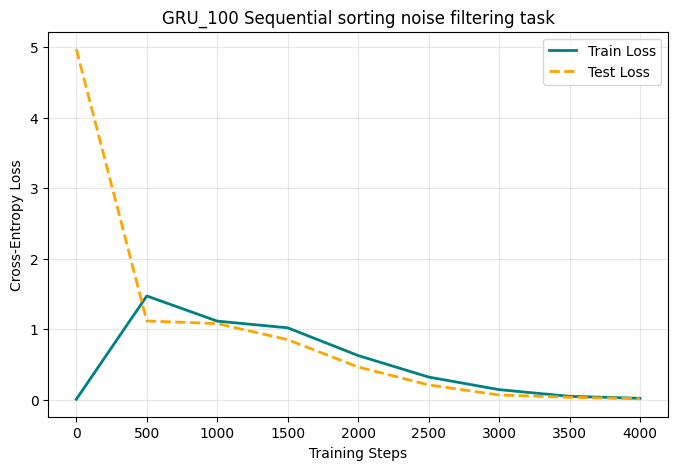

STEP: 4000 | TRAIN LOSS: 0.0229 | TEST LOSS: 0.0170


  0%|          | 0/10 [00:00<?, ?it/s]

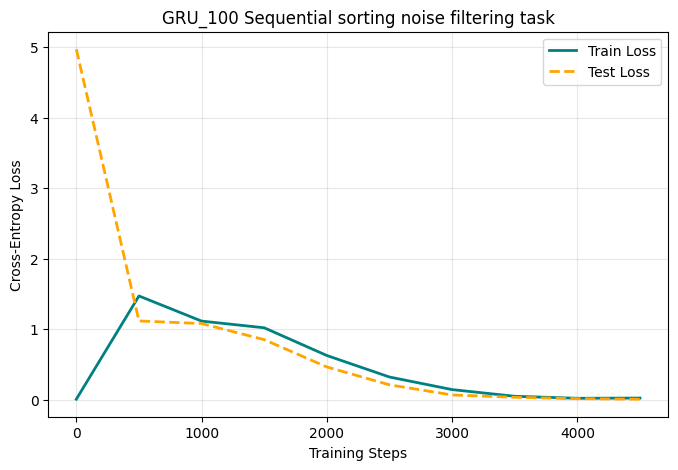

STEP: 4500 | TRAIN LOSS: 0.0259 | TEST LOSS: 0.0095


  0%|          | 0/10 [00:00<?, ?it/s]

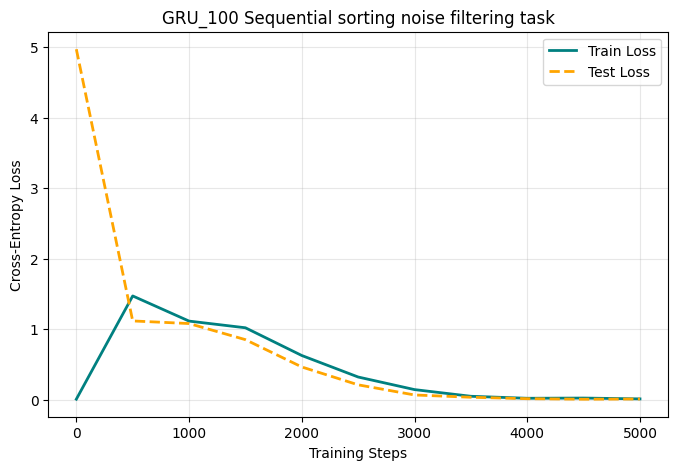

STEP: 5000 | TRAIN LOSS: 0.0143 | TEST LOSS: 0.0126


  0%|          | 0/10 [00:00<?, ?it/s]

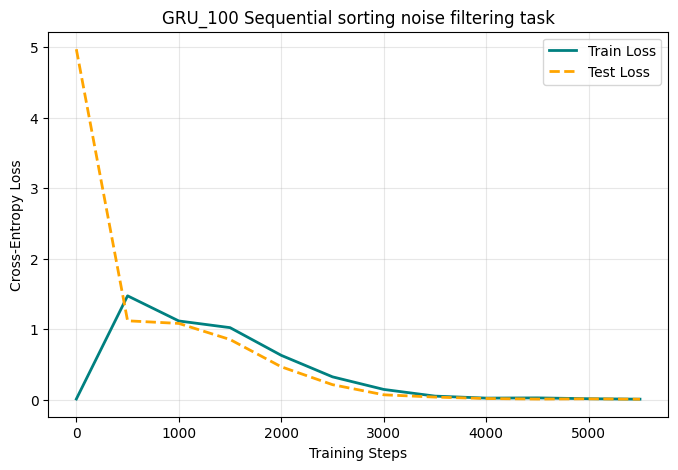

STEP: 5500 | TRAIN LOSS: 0.0079 | TEST LOSS: 0.0071


  0%|          | 0/10 [00:00<?, ?it/s]

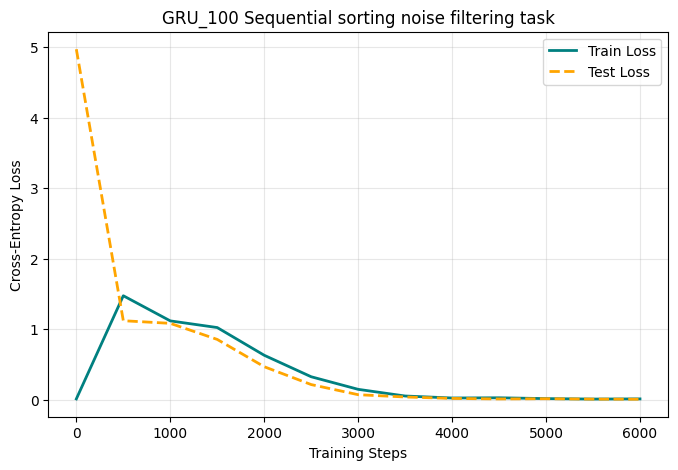

STEP: 6000 | TRAIN LOSS: 0.0103 | TEST LOSS: 0.0056


  0%|          | 0/10 [00:00<?, ?it/s]

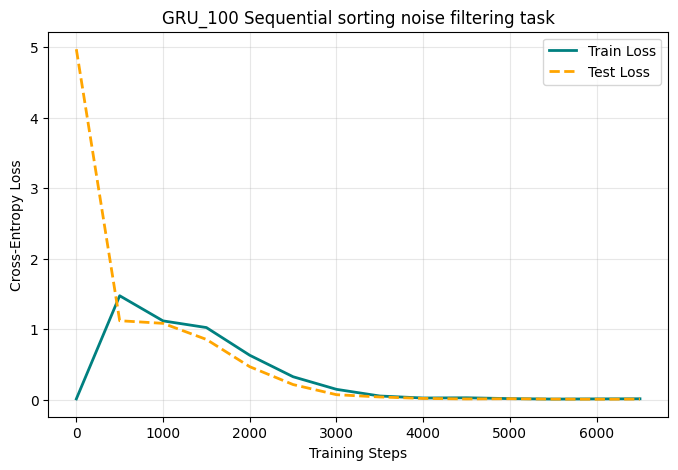

STEP: 6500 | TRAIN LOSS: 0.0120 | TEST LOSS: 0.0074


  0%|          | 0/10 [00:00<?, ?it/s]

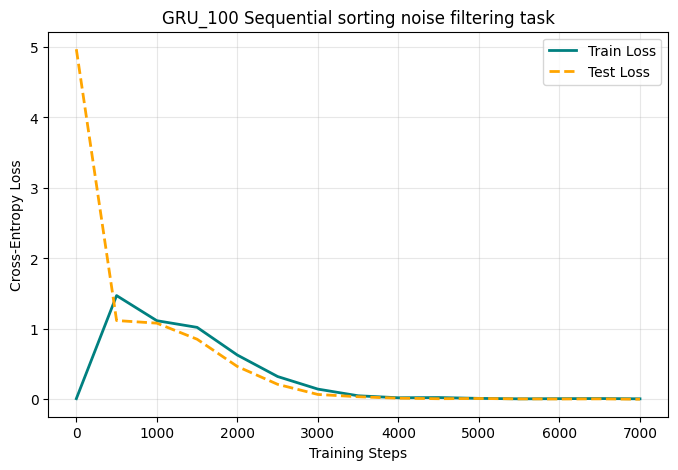

STEP: 7000 | TRAIN LOSS: 0.0081 | TEST LOSS: 0.0022


In [7]:
steps_history = []
train_history = []
test_history = []

run_training_ex3(GRU_model, 
                 batch_size, 
                 total_batches, 
                 test_batches, 
                 copy_size, 
                 buffer_size, 
                 opt_GRU, 
                 test_break=500, 
                 model_name="GRU_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

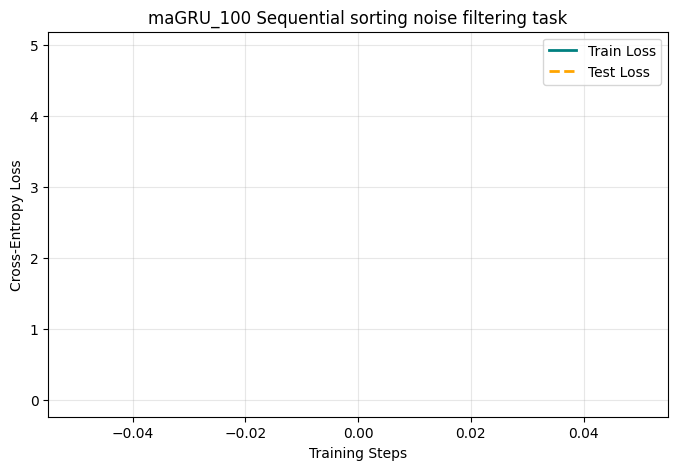

STEP: 0 | TRAIN LOSS: 0.0101 | TEST LOSS: 4.9410


  0%|          | 0/10 [00:00<?, ?it/s]

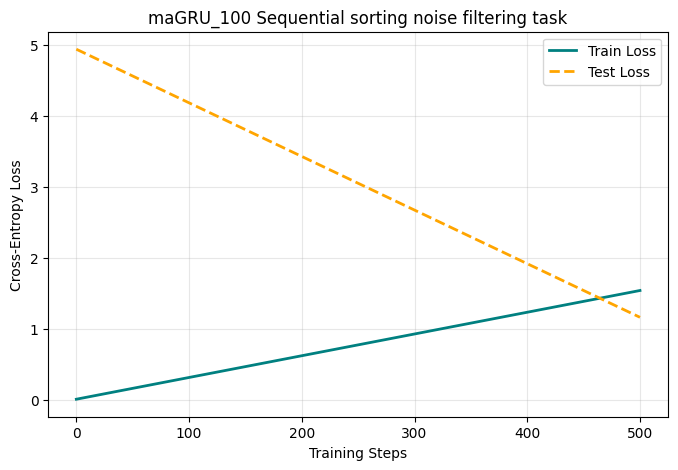

STEP: 500 | TRAIN LOSS: 1.5418 | TEST LOSS: 1.1641


  0%|          | 0/10 [00:00<?, ?it/s]

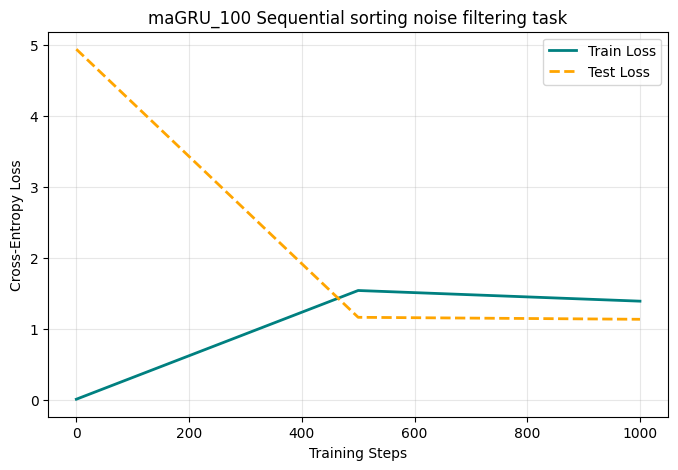

STEP: 1000 | TRAIN LOSS: 1.3915 | TEST LOSS: 1.1362


  0%|          | 0/10 [00:00<?, ?it/s]

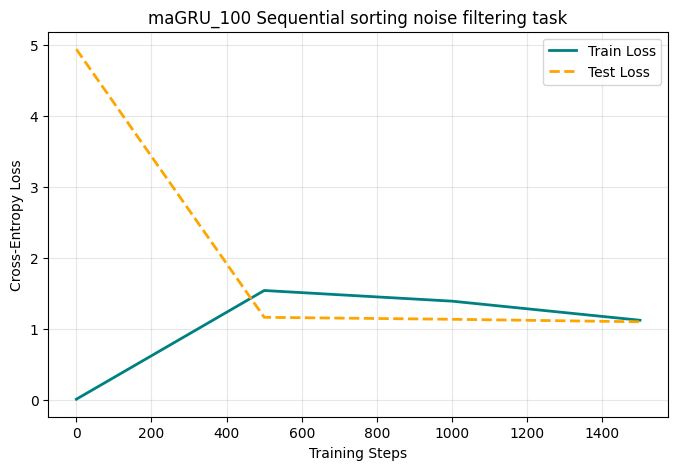

STEP: 1500 | TRAIN LOSS: 1.1227 | TEST LOSS: 1.1010


  0%|          | 0/10 [00:00<?, ?it/s]

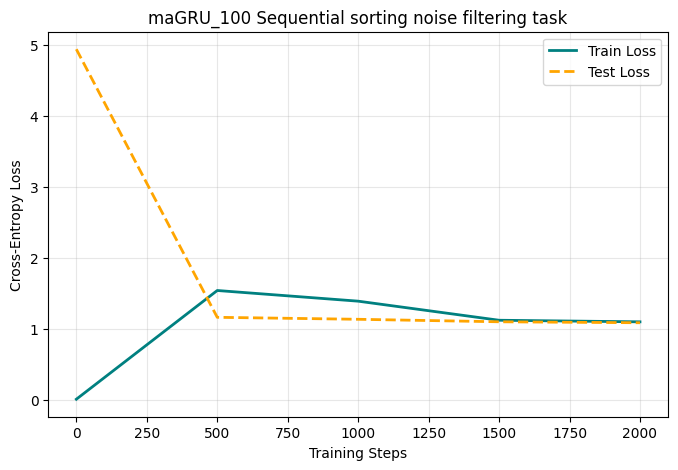

STEP: 2000 | TRAIN LOSS: 1.1003 | TEST LOSS: 1.0875


  0%|          | 0/10 [00:00<?, ?it/s]

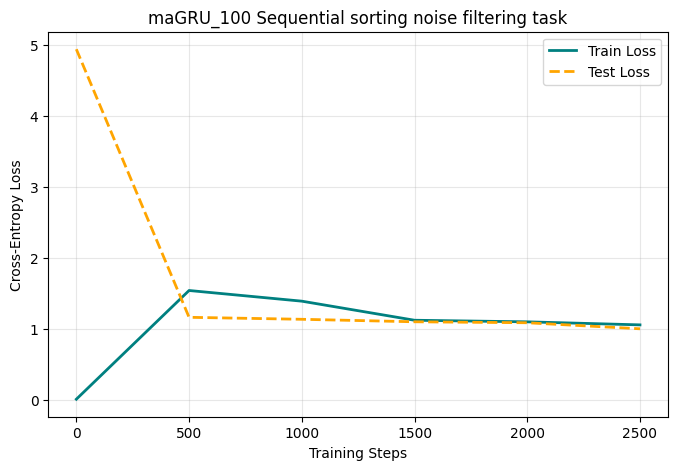

STEP: 2500 | TRAIN LOSS: 1.0575 | TEST LOSS: 1.0022


  0%|          | 0/10 [00:00<?, ?it/s]

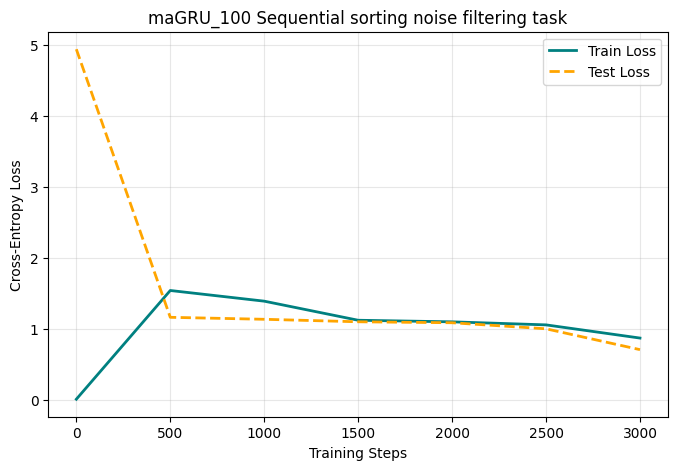

STEP: 3000 | TRAIN LOSS: 0.8717 | TEST LOSS: 0.7085


  0%|          | 0/10 [00:00<?, ?it/s]

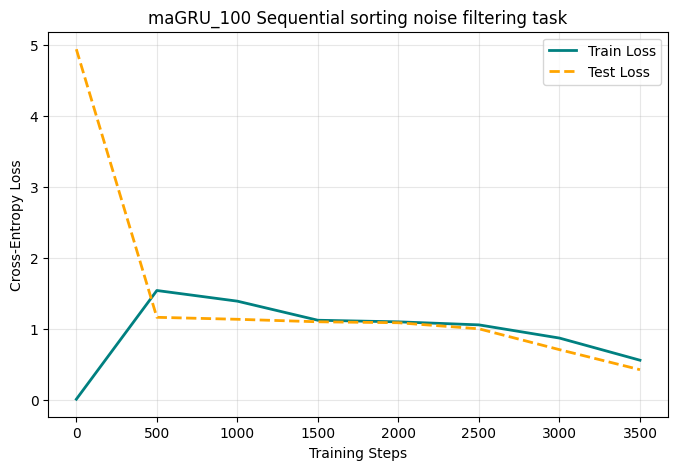

STEP: 3500 | TRAIN LOSS: 0.5596 | TEST LOSS: 0.4260


  0%|          | 0/10 [00:00<?, ?it/s]

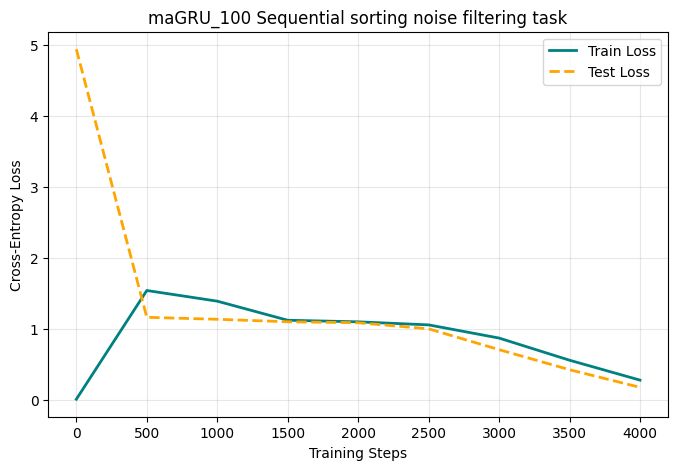

STEP: 4000 | TRAIN LOSS: 0.2792 | TEST LOSS: 0.1776


  0%|          | 0/10 [00:00<?, ?it/s]

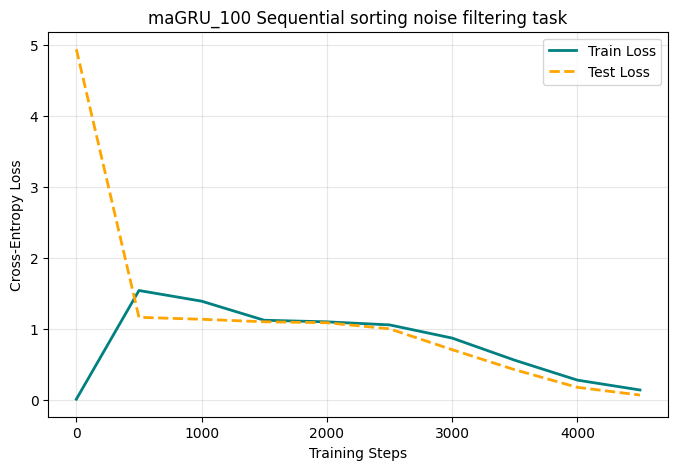

STEP: 4500 | TRAIN LOSS: 0.1402 | TEST LOSS: 0.0685


  0%|          | 0/10 [00:00<?, ?it/s]

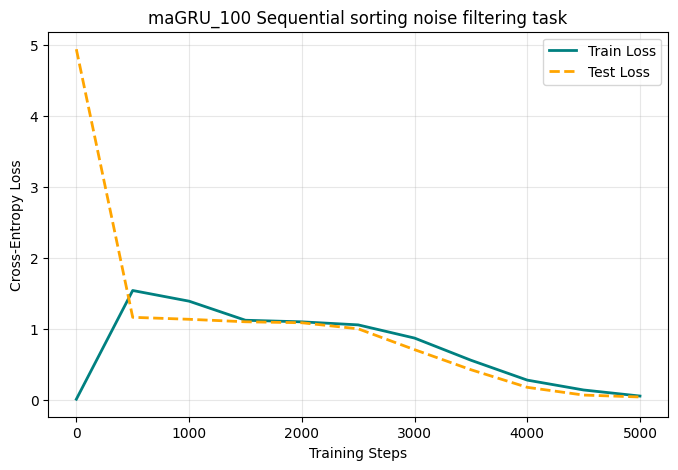

STEP: 5000 | TRAIN LOSS: 0.0548 | TEST LOSS: 0.0417


  0%|          | 0/10 [00:00<?, ?it/s]

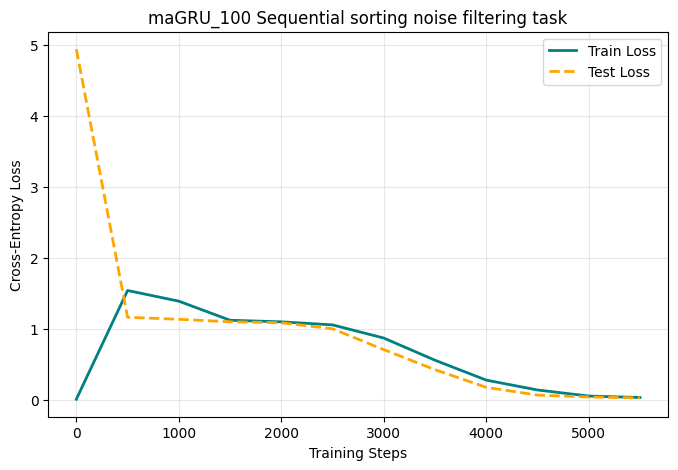

STEP: 5500 | TRAIN LOSS: 0.0343 | TEST LOSS: 0.0285


  0%|          | 0/10 [00:00<?, ?it/s]

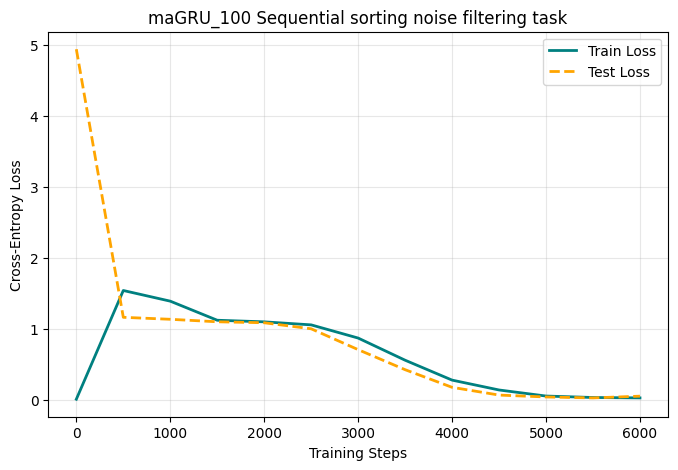

STEP: 6000 | TRAIN LOSS: 0.0288 | TEST LOSS: 0.0532


  0%|          | 0/10 [00:00<?, ?it/s]

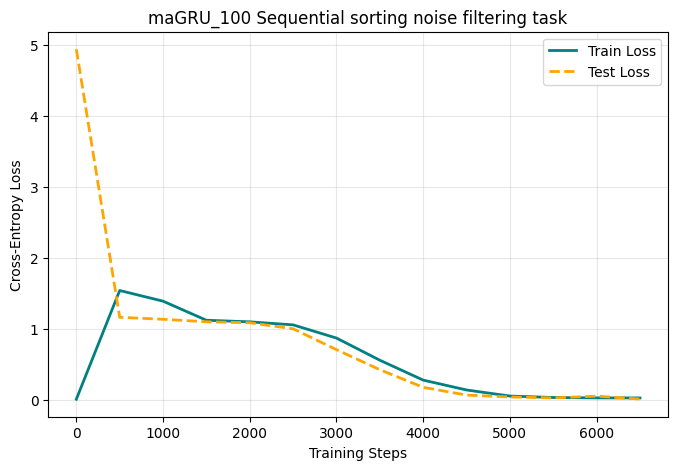

STEP: 6500 | TRAIN LOSS: 0.0281 | TEST LOSS: 0.0123


  0%|          | 0/10 [00:00<?, ?it/s]

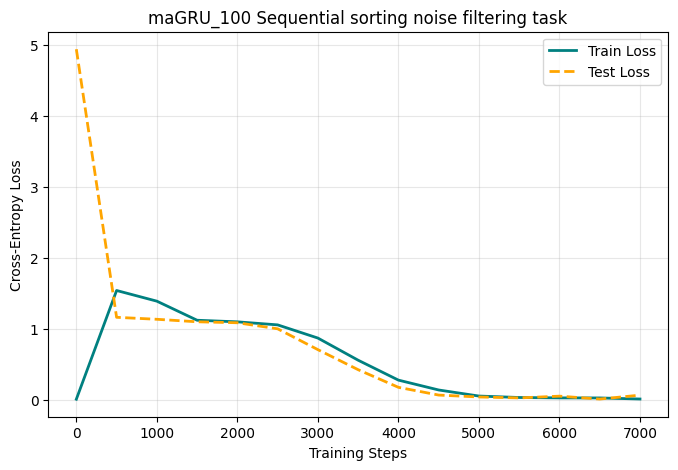

STEP: 7000 | TRAIN LOSS: 0.0130 | TEST LOSS: 0.0674


In [8]:
steps_history = []
train_history = []
test_history = []

run_training_ex3(maGRU_model, 
                 batch_size, 
                 total_batches, 
                 test_batches, 
                 copy_size, 
                 buffer_size, 
                 opt_maGRU, 
                 test_break=500, 
                 model_name="maGRU_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

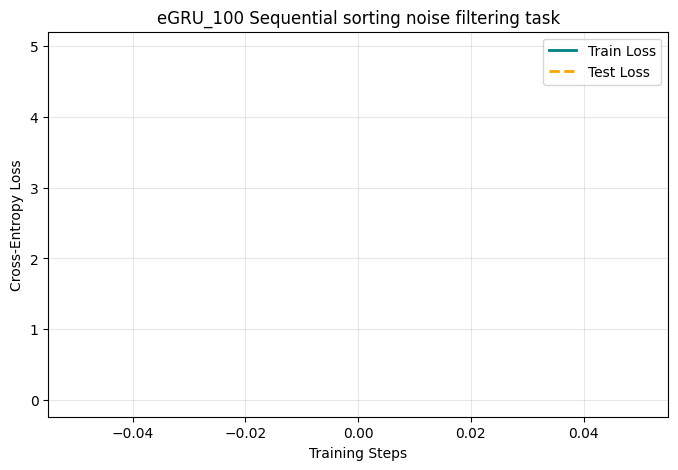

STEP: 0 | TRAIN LOSS: 0.0101 | TEST LOSS: 4.9569


  0%|          | 0/10 [00:00<?, ?it/s]

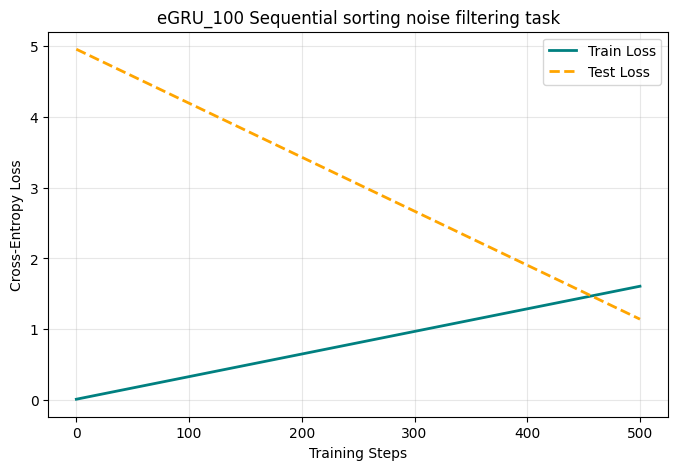

STEP: 500 | TRAIN LOSS: 1.6070 | TEST LOSS: 1.1415


  0%|          | 0/10 [00:00<?, ?it/s]

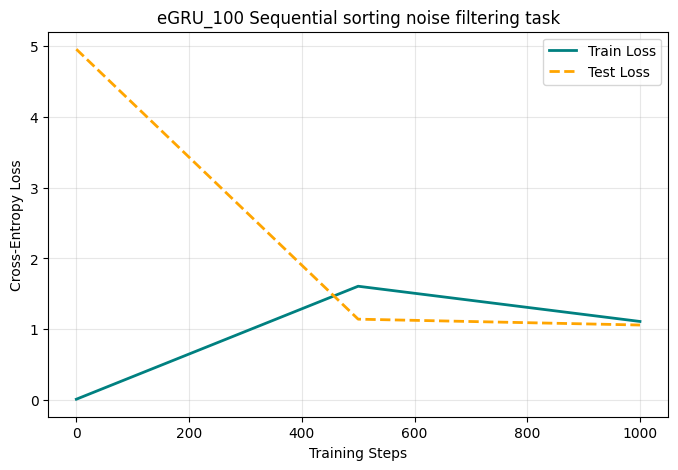

STEP: 1000 | TRAIN LOSS: 1.1091 | TEST LOSS: 1.0587


  0%|          | 0/10 [00:00<?, ?it/s]

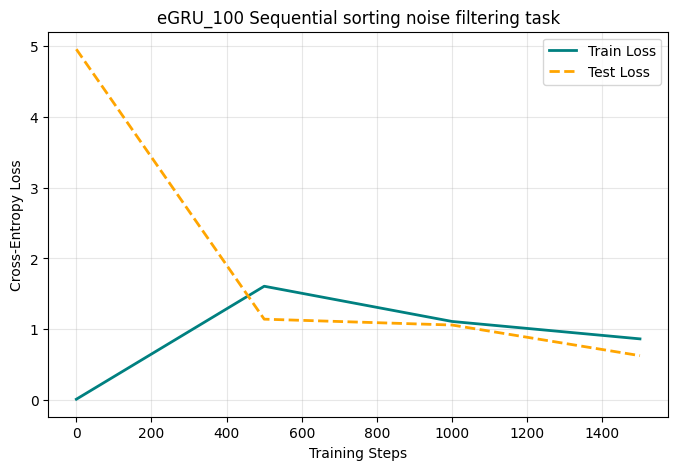

STEP: 1500 | TRAIN LOSS: 0.8631 | TEST LOSS: 0.6257


  0%|          | 0/10 [00:00<?, ?it/s]

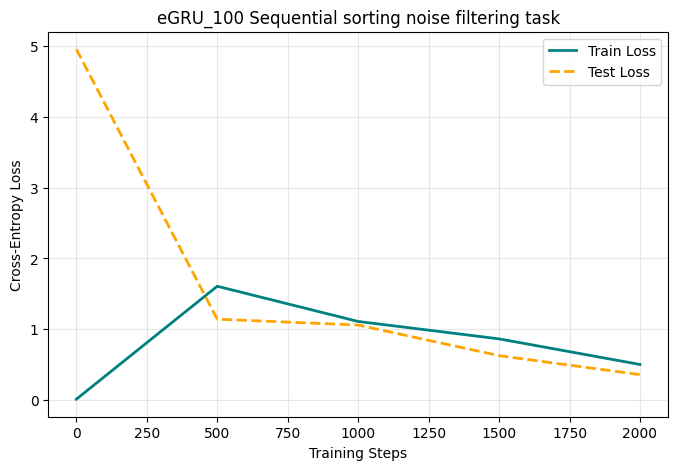

STEP: 2000 | TRAIN LOSS: 0.5013 | TEST LOSS: 0.3574


  0%|          | 0/10 [00:00<?, ?it/s]

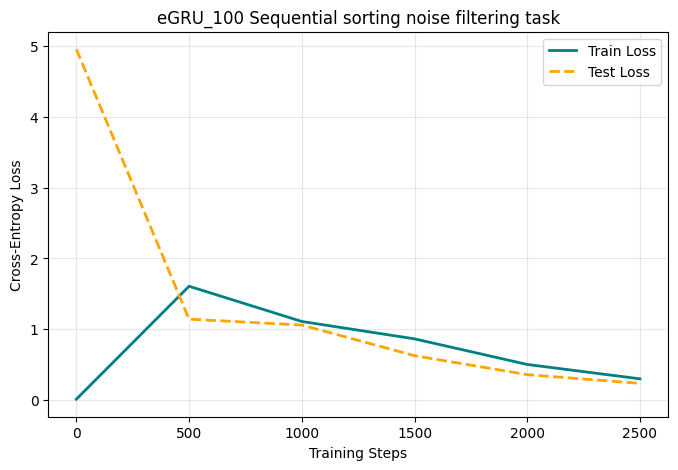

STEP: 2500 | TRAIN LOSS: 0.2982 | TEST LOSS: 0.2341


  0%|          | 0/10 [00:00<?, ?it/s]

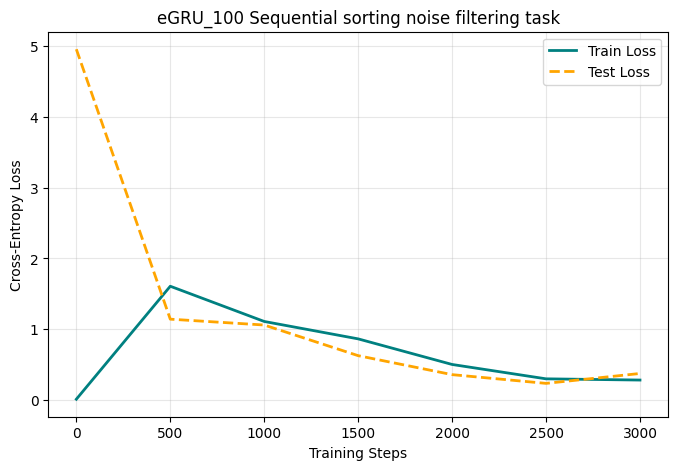

STEP: 3000 | TRAIN LOSS: 0.2809 | TEST LOSS: 0.3739


  0%|          | 0/10 [00:00<?, ?it/s]

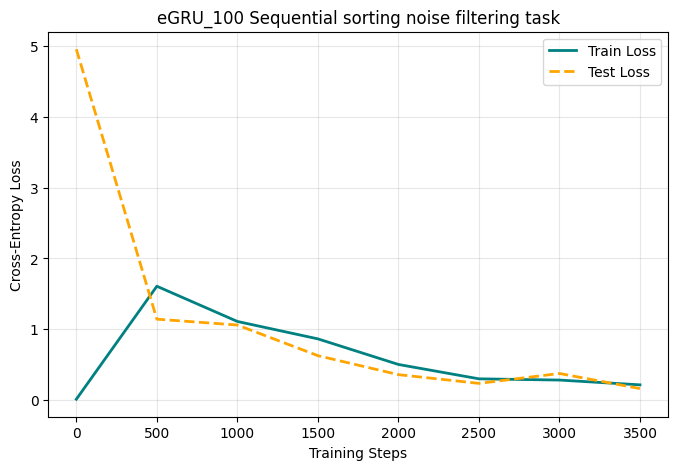

STEP: 3500 | TRAIN LOSS: 0.2132 | TEST LOSS: 0.1606


  0%|          | 0/10 [00:00<?, ?it/s]

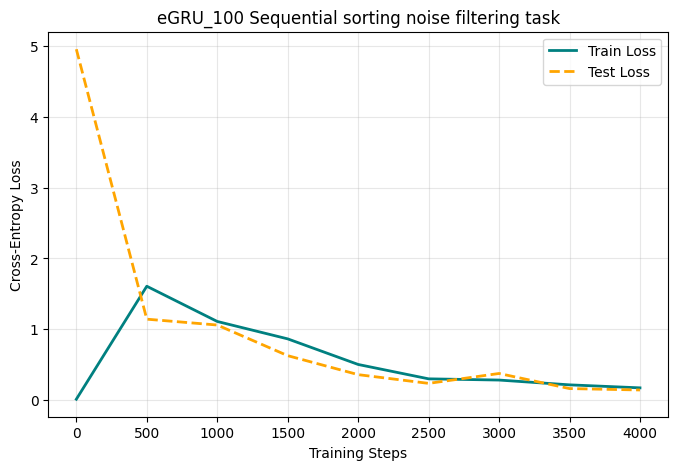

STEP: 4000 | TRAIN LOSS: 0.1708 | TEST LOSS: 0.1407


  0%|          | 0/10 [00:00<?, ?it/s]

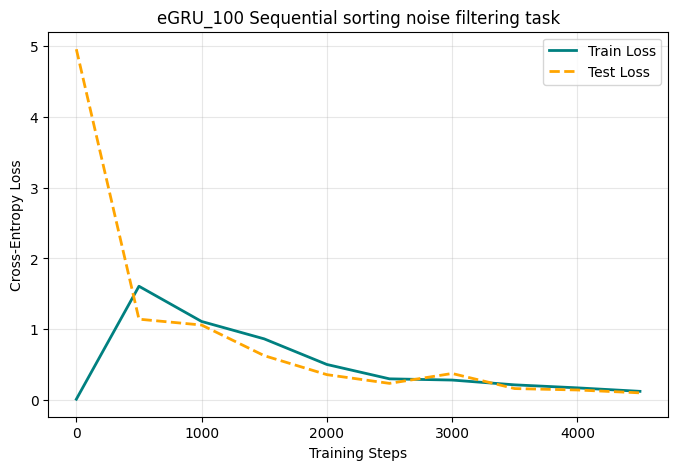

STEP: 4500 | TRAIN LOSS: 0.1214 | TEST LOSS: 0.1002


  0%|          | 0/10 [00:00<?, ?it/s]

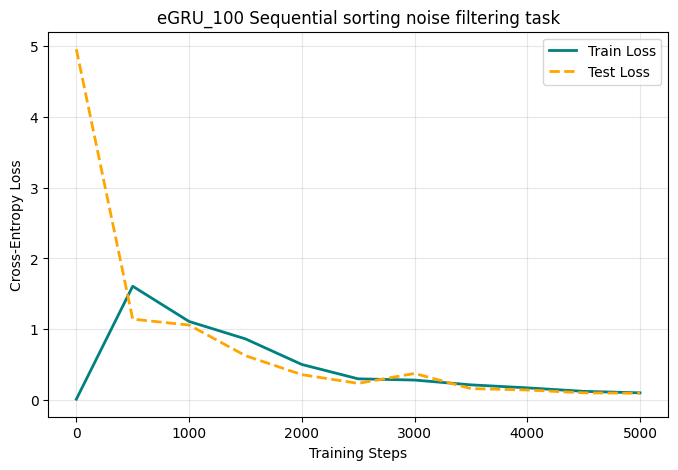

STEP: 5000 | TRAIN LOSS: 0.1001 | TEST LOSS: 0.0939


  0%|          | 0/10 [00:00<?, ?it/s]

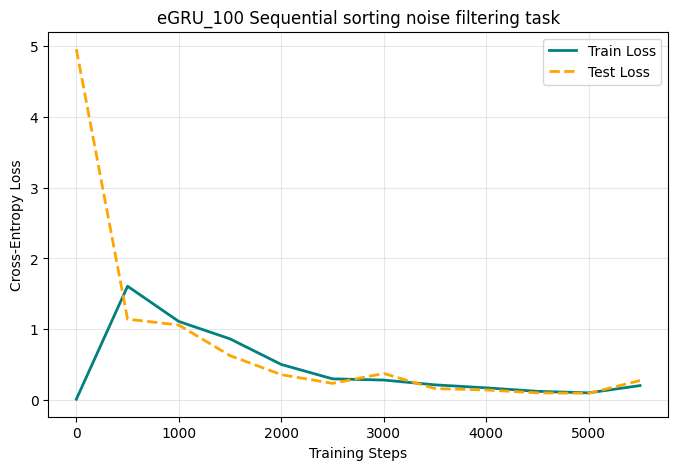

STEP: 5500 | TRAIN LOSS: 0.2026 | TEST LOSS: 0.2741


  0%|          | 0/10 [00:00<?, ?it/s]

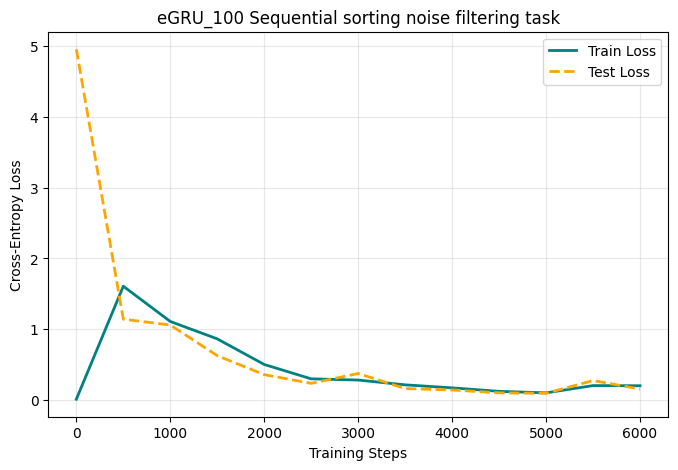

STEP: 6000 | TRAIN LOSS: 0.2005 | TEST LOSS: 0.1541


  0%|          | 0/10 [00:00<?, ?it/s]

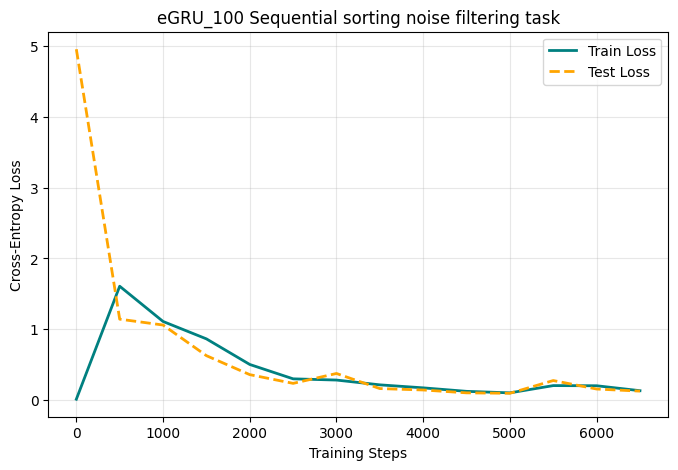

STEP: 6500 | TRAIN LOSS: 0.1307 | TEST LOSS: 0.1245


  0%|          | 0/10 [00:00<?, ?it/s]

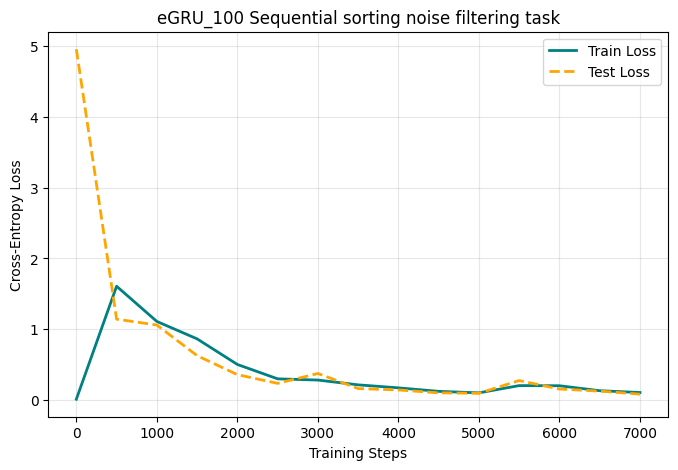

STEP: 7000 | TRAIN LOSS: 0.1046 | TEST LOSS: 0.0817


In [9]:
steps_history = []
train_history = []
test_history = []

run_training_ex3(eGRU_model, 
                 batch_size, 
                 total_batches, 
                 test_batches, 
                 copy_size, 
                 buffer_size, 
                 opt_eGRU, 
                 test_break=500, 
                 model_name="eGRU_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

## Testing the models!

In [5]:
def load_model(filename, device, model, optimizer):
    checkpoint = torch.load(filename, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch_saved"] + 1
    return start_epoch

In [6]:
hid=256
emb=len(vocab)
lr=1e-3
batch_size=32
test_batches=100

steps_history = []
train_history = []
test_history = []

In [7]:


load_model("./models/ex3/mLSTM_100_ex3_epoch_7000.pt", "cuda", mLSTM_model, opt_mLSTM)
load_model("./models/ex3/mLSTMLite_100_ex3_epoch_7000.pt", "cuda", mLSTMLite_model, opt_mLSTMLite)
load_model("./models/ex3/sLSTM_100_ex3_epoch_7000.pt", "cuda", sLSTM_model, opt_sLSTM)
load_model("./models/ex3/MGU_100_ex3_epoch_7000.pt", "cuda", MGU_model, opt_MGU)
load_model("./models/ex3/maGRU_100_ex3_epoch_7000.pt", "cuda", maGRU_model, opt_maGRU)
load_model("./models/ex3/GRU_100_ex3_epoch_7000.pt", "cuda", GRU_model, opt_GRU)
load_model("./models/ex3/eGRU_100_ex3_epoch_7000.pt", "cuda", eGRU_model, opt_eGRU)

7001

In [12]:

ex1_mlstm_50   =  evaluate_ex3(mLSTM_model, copy_size=10, teacher_forcing=False, buffer_size=15,   total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstm_100  =  evaluate_ex3(mLSTM_model, copy_size=10, teacher_forcing=False, buffer_size=25,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstm_250  =  evaluate_ex3(mLSTM_model, copy_size=10, teacher_forcing=False, buffer_size=50,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstm_500  =  evaluate_ex3(mLSTM_model, copy_size=10, teacher_forcing=False, buffer_size=75,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstm_750  =  evaluate_ex3(mLSTM_model, copy_size=10, teacher_forcing=False, buffer_size=100,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstm_1000 = evaluate_ex3(mLSTM_model,  copy_size=10, teacher_forcing=False,  buffer_size=250, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("mLSTM bracket closing difference at buffer_size=50: ",   ex1_mlstm_50)
print("mLSTM bracket closing difference at buffer_size=100: ",  ex1_mlstm_100)
print("mLSTM bracket closing difference at buffer_size=250: ",  ex1_mlstm_250)
print("mLSTM bracket closing difference at buffer_size=500: ",  ex1_mlstm_500)
print("mLSTM bracket closing difference at buffer_size=750: ",  ex1_mlstm_750)
print("mLSTM bracket closing difference at buffer_size=1000: ", ex1_mlstm_1000)

Testing model at  15  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  25  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  50  buffer_size.


...

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

mLSTM bracket closing difference at buffer_size=50:  0.5782797159534869
mLSTM bracket closing difference at buffer_size=100:  0.5715965475186263
mLSTM bracket closing difference at buffer_size=250:  0.5662747689402929
mLSTM bracket closing difference at buffer_size=500:  0.5629022434206292
mLSTM bracket closing difference at buffer_size=750:  0.5643564462661743
mLSTM bracket closing difference at buffer_size=1000:  0.6529703093047189


In [13]:

ex1_mlstmlite_50   = evaluate_ex3(mLSTMLite_model, copy_size=10, teacher_forcing=False, buffer_size=15,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstmlite_100  = evaluate_ex3(mLSTMLite_model, copy_size=10, teacher_forcing=False, buffer_size=25,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstmlite_250  = evaluate_ex3(mLSTMLite_model, copy_size=10, teacher_forcing=False, buffer_size=50,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstmlite_500  = evaluate_ex3(mLSTMLite_model, copy_size=10, teacher_forcing=False, buffer_size=75,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstmlite_750  = evaluate_ex3(mLSTMLite_model, copy_size=10, teacher_forcing=False, buffer_size=100, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstmlite_1000 = evaluate_ex3(mLSTMLite_model, copy_size=10, teacher_forcing=False, buffer_size=250, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("mLSTMLite bracket closing difference at buffer_size=50: ",   ex1_mlstmlite_50)
print("mLSTMLite bracket closing difference at buffer_size=100: ",  ex1_mlstmlite_100)
print("mLSTMLite bracket closing difference at buffer_size=250: ",  ex1_mlstmlite_250)
print("mLSTMLite bracket closing difference at buffer_size=500: ",  ex1_mlstmlite_500)
print("mLSTMLite bracket closing difference at buffer_size=750: ",  ex1_mlstmlite_750)
print("mLSTMLite bracket closing difference at buffer_size=1000: ", ex1_mlstmlite_1000)

Testing model at  15  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  25  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  50  buffer_size.


...

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

mLSTMLite bracket closing difference at buffer_size=50:  0.5800123863881177
mLSTMLite bracket closing difference at buffer_size=100:  0.5795482745265016
mLSTMLite bracket closing difference at buffer_size=250:  0.5809096629076665
mLSTMLite bracket closing difference at buffer_size=500:  0.5627784758511156
mLSTMLite bracket closing difference at buffer_size=750:  0.5740099118487669
mLSTMLite bracket closing difference at buffer_size=1000:  0.6972153599899594


In [14]:
ex1_cgru_50 =   evaluate_ex3(GRU_model, copy_size=10, teacher_forcing=False, buffer_size=50, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_cgru_100 =  evaluate_ex3(GRU_model, copy_size=10, teacher_forcing=False, buffer_size=100, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_cgru_250 =  evaluate_ex3(GRU_model, copy_size=10, teacher_forcing=False, buffer_size=250, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_cgru_500 =  evaluate_ex3(GRU_model, copy_size=10, teacher_forcing=False, buffer_size=500, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_cgru_750 =  evaluate_ex3(GRU_model, copy_size=10, teacher_forcing=False, buffer_size=750, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_cgru_1000 = evaluate_ex3(GRU_model, copy_size=10, teacher_forcing=False, buffer_size=1000, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("GRU noise sorting difference at buffer_size=50: ", ex1_cgru_50)
print("GRU noise sorting difference at buffer_size=100: ", ex1_cgru_100)
print("GRU noise sorting difference at buffer_size=250: ", ex1_cgru_250)
print("GRU noise sorting difference at buffer_size=500: ", ex1_cgru_500)
print("GRU noise sorting difference at buffer_size=750: ", ex1_cgru_750)
print("GRU noise sorting difference at buffer_size=1000: ", ex1_cgru_1000)

Testing model at  50  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


...

Testing model at  750  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  1000  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

GRU noise sorting difference at buffer_size=50:  0.002289604003734813
GRU noise sorting difference at buffer_size=100:  0.0008353960566628392
GRU noise sorting difference at buffer_size=250:  0.029084159001376075
GRU noise sorting difference at buffer_size=500:  0.2583230248477199
GRU noise sorting difference at buffer_size=750:  0.37936262889663774
GRU noise sorting difference at buffer_size=1000:  0.4614170854634578


In [15]:
ex1_mgu_50 =     evaluate_ex3(MGU_model, copy_size=10, buffer_size=50, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mgu_100 =   evaluate_ex3(MGU_model, copy_size=10, buffer_size=100, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mgu_250 =   evaluate_ex3(MGU_model, copy_size=10, buffer_size=250, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mgu_500 =   evaluate_ex3(MGU_model, copy_size=10, buffer_size=500, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mgu_750 =   evaluate_ex3(MGU_model, copy_size=10, buffer_size=750, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mgu_1000 = evaluate_ex3(MGU_model, copy_size=10, buffer_size=1000, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("MGU noise sorting difference at buffer_size=50: ",   ex1_mgu_50)
print("MGU noise sorting difference at buffer_size=100: ",  ex1_mgu_100)
print("MGU noise sorting difference at buffer_size=250: ",  ex1_mgu_250)
print("MGU noise sorting difference at buffer_size=500: ",  ex1_mgu_500)
print("MGU noise sorting difference at buffer_size=750: ",  ex1_mgu_750)
print("MGU noise sorting difference at buffer_size=1000: ", ex1_mgu_1000)

Testing model at  50  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


...

Testing model at  750  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  1000  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

MGU noise sorting difference at buffer_size=50:  0.0036819307663763807
MGU noise sorting difference at buffer_size=100:  0.0010519802206112902
MGU noise sorting difference at buffer_size=250:  0.018688119129545176
MGU noise sorting difference at buffer_size=500:  0.13236386358442873
MGU noise sorting difference at buffer_size=750:  0.29672030263608046
MGU noise sorting difference at buffer_size=1000:  0.3990717884337548


In [16]:
ex1_slstm_50 =     evaluate_ex3(sLSTM_model, copy_size=10, buffer_size=50, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_slstm_100 =   evaluate_ex3(sLSTM_model, copy_size=10, buffer_size=100, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_slstm_250 =   evaluate_ex3(sLSTM_model, copy_size=10, buffer_size=250, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_slstm_500 =   evaluate_ex3(sLSTM_model, copy_size=10, buffer_size=500, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_slstm_750 =   evaluate_ex3(sLSTM_model, copy_size=10, buffer_size=750, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_slstm_1000 = evaluate_ex3(sLSTM_model, copy_size=10, buffer_size=1000, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("sLSTM noise sorting difference at buffer_size=50: ",   ex1_slstm_50)
print("sLSTM noise sorting difference at buffer_size=100: ",  ex1_slstm_100)
print("sLSTM noise sorting difference at buffer_size=250: ",  ex1_slstm_250)
print("sLSTM noise sorting difference at buffer_size=500: ",  ex1_slstm_500)
print("sLSTM noise sorting difference at buffer_size=750: ",  ex1_slstm_750)
print("sLSTM noise sorting difference at buffer_size=1000: ", ex1_slstm_1000)

Testing model at  50  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


...

Testing model at  750  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  1000  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

sLSTM noise sorting difference at buffer_size=50:  0.29176980743903924
sLSTM noise sorting difference at buffer_size=100:  0.010891089289642797
sLSTM noise sorting difference at buffer_size=250:  0.5996596647961305
sLSTM noise sorting difference at buffer_size=500:  0.6971534779756376
sLSTM noise sorting difference at buffer_size=750:  0.7151609010035449
sLSTM noise sorting difference at buffer_size=1000:  0.7317141200056171


In [17]:
ex1_magru_50 =     evaluate_ex3(maGRU_model, copy_size=10, buffer_size=50, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_magru_100 =   evaluate_ex3(maGRU_model, copy_size=10, buffer_size=100, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_magru_250 =   evaluate_ex3(maGRU_model, copy_size=10, buffer_size=250, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_magru_500 =   evaluate_ex3(maGRU_model, copy_size=10, buffer_size=500, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_magru_750 =   evaluate_ex3(maGRU_model, copy_size=10, buffer_size=750, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_magru_1000 = evaluate_ex3(maGRU_model, copy_size=10, buffer_size=1000, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("maGRU noise sorting difference at buffer_size=50: ",   ex1_magru_50)
print("maGRU noise sorting difference at buffer_size=100: ",  ex1_magru_100)
print("maGRU noise sorting difference at buffer_size=250: ",  ex1_magru_250)
print("maGRU noise sorting difference at buffer_size=500: ",  ex1_magru_500)
print("maGRU noise sorting difference at buffer_size=750: ",  ex1_magru_750)
print("maGRU noise sorting difference at buffer_size=1000: ", ex1_magru_1000)

Testing model at  50  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


...

Testing model at  750  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  1000  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

maGRU noise sorting difference at buffer_size=50:  0.048391090065130205
maGRU noise sorting difference at buffer_size=100:  0.03799505015410999
maGRU noise sorting difference at buffer_size=250:  0.054888614812994944
maGRU noise sorting difference at buffer_size=500:  0.15433168544037507
maGRU noise sorting difference at buffer_size=750:  0.25018564810847294
maGRU noise sorting difference at buffer_size=1000:  0.29969059904613116


In [8]:
ex1_eGRU_50 =     evaluate_ex3(eGRU_model, copy_size=10, buffer_size=50, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_eGRU_100 =   evaluate_ex3(eGRU_model, copy_size=10, buffer_size=100, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_eGRU_250 =   evaluate_ex3(eGRU_model, copy_size=10, buffer_size=250, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_eGRU_500 =   evaluate_ex3(eGRU_model, copy_size=10, buffer_size=500, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_eGRU_750 =   evaluate_ex3(eGRU_model, copy_size=10, buffer_size=750, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_eGRU_1000 = evaluate_ex3(eGRU_model, copy_size=10, buffer_size=1000, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("eGRU noise sorting difference at buffer_size=50: ",   ex1_eGRU_50)
print("eGRU noise sorting difference at buffer_size=100: ",  ex1_eGRU_100)
print("eGRU noise sorting difference at buffer_size=250: ",  ex1_eGRU_250)
print("eGRU noise sorting difference at buffer_size=500: ",  ex1_eGRU_500)
print("eGRU noise sorting difference at buffer_size=750: ",  ex1_eGRU_750)
print("eGRU noise sorting difference at buffer_size=1000: ", ex1_eGRU_1000)

Testing model at  50  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


...

Testing model at  750  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  1000  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

eGRU noise sorting difference at buffer_size=50:  0.06231435733192628
eGRU noise sorting difference at buffer_size=100:  0.06287128789958978
eGRU noise sorting difference at buffer_size=250:  0.07459777385217718
eGRU noise sorting difference at buffer_size=500:  0.07240099126085786
eGRU noise sorting difference at buffer_size=750:  0.07329826872095023
eGRU noise sorting difference at buffer_size=1000:  0.07431930792287435


In [7]:
ex1_lstm_50   =  evaluate_ex3(LSTM_model, copy_size=10, teacher_forcing=False, buffer_size=15,   total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_lstm_100  =  evaluate_ex3(LSTM_model, copy_size=10, teacher_forcing=False, buffer_size=25,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_lstm_250  =  evaluate_ex3(LSTM_model, copy_size=10, teacher_forcing=False, buffer_size=50,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_lstm_500  =  evaluate_ex3(LSTM_model, copy_size=10, teacher_forcing=False, buffer_size=75,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_lstm_750  =  evaluate_ex3(LSTM_model, copy_size=10, teacher_forcing=False, buffer_size=100,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_lstm_1000 =  evaluate_ex3(LSTM_model,  copy_size=10, teacher_forcing=False,  buffer_size=250, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("LSTM bracket closing difference at buffer_size=50: ",   ex1_lstm_50)
print("LSTM bracket closing difference at buffer_size=100: ",  ex1_lstm_100)
print("LSTM bracket closing difference at buffer_size=250: ",  ex1_lstm_250)
print("LSTM bracket closing difference at buffer_size=500: ",  ex1_lstm_500)
print("LSTM bracket closing difference at buffer_size=750: ",  ex1_lstm_750)
print("LSTM bracket closing difference at buffer_size=1000: ", ex1_lstm_1000)

Testing model at  15  buffer_size.


  0%|          | 0/11 [00:00<?, ?it/s]

Testing model at  25  buffer_size.


  0%|          | 0/11 [00:00<?, ?it/s]

Testing model at  50  buffer_size.


...

Testing model at  100  buffer_size.


  0%|          | 0/11 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


  0%|          | 0/11 [00:00<?, ?it/s]

LSTM bracket closing difference at buffer_size=50:  0.7607954686338251
LSTM bracket closing difference at buffer_size=100:  0.7607954686338251
LSTM bracket closing difference at buffer_size=250:  0.775568198073994
LSTM bracket closing difference at buffer_size=500:  0.7718750130046498
LSTM bracket closing difference at buffer_size=750:  0.7616477446122603
LSTM bracket closing difference at buffer_size=1000:  0.7707386396147988


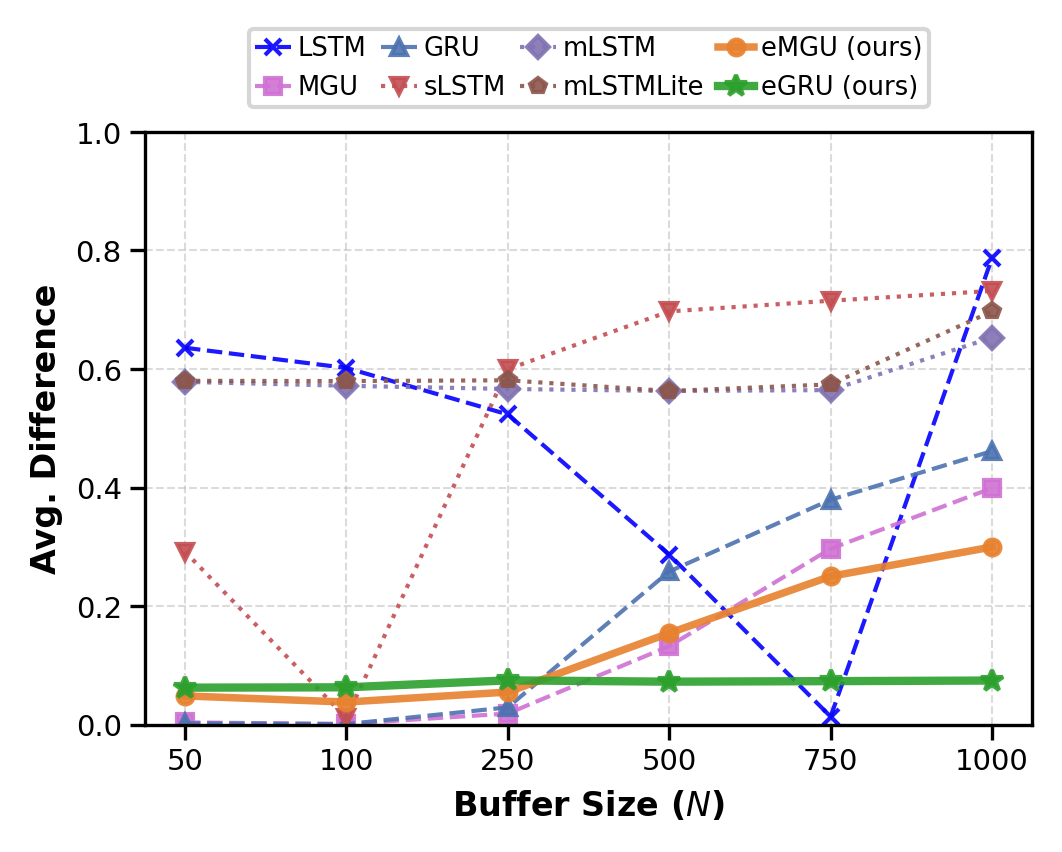

In [8]:
standard_gru = [
    0.002289604003734813,
     0.0008353960566628392,
     0.029084159001376075,
     0.2583230248477199,
     0.37936262889663774,
      0.4614170854634578
]

standard_lstm = [
    0.6357954632152211,
     0.601704559542916,
     0.5232954648408022,
     0.28693182360042224,
     0.013352272883904252,
      0.787215915593234,
]


egru = [
    0.06231435733192628,
     0.06287128789958978,
     0.07459777385217718,
     0.07240099126085786,
     0.07329826872095023,
      0.07431930792287435
]

magru = [
    0.048391090065130205,
     0.03799505015410999,
     0.054888614812994944,
     0.15433168544037507,
     0.25018564810847294,
      0.29969059904613116
]

MGU = [
    0.0036819307663763807,
     0.0010519802206112902,
     0.018688119129545176,
     0.13236386358442873,
     0.29672030263608046,
      0.3990717884337548
]

sLSTM = [
    0.29176980743903924,
     0.010891089289642797,
     0.5996596647961305,
     0.6971534779756376,
     0.7151609010035449,
      0.7317141200056171
]

mLSTM = [
   0.5782797159534869,
    0.5715965475186263,
    0.5662747689402929,
    0.5629022434206292,
    0.5643564462661743,
     0.6529703093047189
]
mLSTMLite = [
0.5800123863881177,
 0.5795482745265016,
 0.5809096629076665,
 0.5627784758511156,
 0.5740099118487669,
  0.6972153599899594
]


import matplotlib.pyplot as plt
import numpy as np

# Data

buffer_sizes = ["50", "100", "250", "500", "750", "1000"]


# --- Single Column Plot Dimensions ---
fig, ax = plt.subplots(figsize=(3.4, 2.7), dpi=300)

# (Label, Data, Color, Marker, Linestyle, LineWidth)
# "Our approach" models get thicker solid lines to naturally stand out
models = [
    ("LSTM", standard_lstm, "#0400FF", "x", "--", 1.0),
    ("MGU", MGU, "#D071D3", "s", "--", 1.0),
    ("GRU", standard_gru, "#4C72B0", "^", "--", 1.0),
    ("sLSTM", sLSTM, "#C44E52", "v", ":", 1.0),
    ("mLSTM", mLSTM, "#8172B2", "D", ":", 1.0),
    ("mLSTMLite", mLSTMLite, "#8C564B", "p", ":", 1.0),
    ("eMGU (ours)", magru, "#E7812E", "o", "-", 1.8),
    ("eGRU (ours)", egru, "#2CA02C", "*", "-", 2.0),
]

x = np.arange(len(buffer_sizes))

for label, data, color, marker, ls, lw in models:
    ax.plot(
        x,
        data,
        label=label,
        color=color,
        marker=marker,
        markersize=3.8 if marker != "*" else 5.5,
        linestyle=ls,
        linewidth=lw,
        alpha=0.9,
    )

# --- Axes & Labels ---
ax.set_xlabel("Buffer Size ($N$)", fontsize=8, fontweight="bold", labelpad=3)
ax.set_ylabel("Avg. Difference", fontsize=8, fontweight="bold", labelpad=3)

ax.set_xticks(x)
ax.set_xticklabels(buffer_sizes, fontsize=7.5)
ax.set_ylim(0, 1.0)
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.tick_params(axis="both", labelsize=7, pad=2)

ax.grid(True, linestyle="--", alpha=0.45, linewidth=0.5)

# --- 2-Row x 4-Column Compact Top Legend ---
ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=4,
    fontsize=6.2,
    frameon=True,
    handlelength=1.4,
    handletextpad=0.25,
    columnspacing=0.55,
    borderpad=0.25,
)

plt.tight_layout(pad=0.2)
plt.savefig("retention_line_1col.pdf", bbox_inches="tight")
plt.show()